# Segmentación B2B PwC Perú · Data Mart v7i

**Notebook autocontenido** — lee los 2 Excel y produce toda la analítica + visualizaciones inline.

**Inputs (en la misma carpeta):**
- `Segmentacion PWC 17.04.xlsx` (1,000 empresas × 114 columnas)
- `HISTORICO FINANZAS 17.04.xlsx` (52,385 transacciones × 25 columnas)

**Pipeline:**
1. Carga + limpieza FIN (margin%, FY26 anualizado x1.25, winsor P5/P95)
2. Agregación por empresa (RUC) desde FIN
3. Feature engineering — 9 variables del Target Score
4. Target Score 0-100 (min-max ponderado)
5. K-Means K=5 → 5 clusters comerciales
6. Churn Risk 5-factor (max 130)
7. Upsell Gap Analysis — P75 por (cluster × Sub-LoS) y por (cluster × Cost Center)
8. Riesgo Basel II — EL = EAD × PD + Monte Carlo VaR(95%)/CVaR(95%) + NRAO + Flag Inconsistencia

**Cómo correr:** `Run All` (Shift+Enter celda por celda). Tarda ~30-60s en una laptop moderna.


In [1]:
# === Imports ===
import os, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from math import pi
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import seaborn as sns

# === Paths (ambos Excel deben estar en la MISMA carpeta que este notebook) ===
HERE = os.getcwd()
SEG_FILE = os.path.join(HERE, "Segmentacion PWC 17.04.xlsx")
FIN_FILE = os.path.join(HERE, "HISTORICO FINANZAS 17.04.xlsx")
print("Buscando en:", HERE)
print("  SEG:", os.path.exists(SEG_FILE), SEG_FILE)
print("  FIN:", os.path.exists(FIN_FILE), FIN_FILE)

# === Estilo PwC ===
PWC_ORANGE = "#D04A02"
PWC_BLUE   = "#1A5490"
PWC_DARK   = "#2D2D2D"
CL_COLORS = {
    "PROTECT & GROW": "#D04A02",
    "ACCELERATE":     "#E88E3B",
    "EXPAND":         "#1A5490",
    "ACTIVATE":       "#7B7B7B",
    "QUALIFY":        "#8B7355",   # taupe/bronce (v7h)
}
labels_order = ["PROTECT & GROW","ACCELERATE","EXPAND","ACTIVATE","QUALIFY"]
verbs = {"PROTECT & GROW":"DEFENDER","ACCELERATE":"ESCALAR","EXPAND":"AMPLIAR",
         "ACTIVATE":"ACTIVAR","QUALIFY":"FILTRAR"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130,
    "font.family":"sans-serif","font.size":10,
    "axes.titlesize":13,"axes.labelsize":10,
    "axes.spines.top":False,"axes.spines.right":False,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


Buscando en: /content
  SEG: True /content/Segmentacion PWC 17.04.xlsx
  FIN: True /content/HISTORICO FINANZAS 17.04.xlsx


## 1. Carga de las 2 fuentes (17.04)


In [2]:
print("1) Cargando fuentes 17.04...")
seg_raw = pd.read_excel(SEG_FILE)
print(f"   SEG: {seg_raw.shape}")

# HISTORICO FINANZAS 17.04 puede venir corrupto (BadZipFile). Si pasa,
# pedimos al usuario reabrir el archivo en Excel y guardarlo de nuevo.
try:
    fin_raw = pd.read_excel(FIN_FILE)
    print(f"   FIN: {fin_raw.shape}")
except Exception as e:
    print(f"   [ERROR] No se pudo leer FIN: {type(e).__name__}: {e}")
    print("   → Abre HISTORICO FINANZAS 17.04.xlsx en Excel, dale Guardar como, y vuelve a correr.")
    raise

display(seg_raw.head(3))
display(fin_raw.head(3))


1) Cargando fuentes 17.04...
   SEG: (1000, 114)
   FIN: (52385, 25)


,ranking_2024,RUC,PRID,razon_social,nombre_comercial,estado,tipo,ciiu,ciiu_rev3_descripcion,ciiu_rev_4,ciiu_rev4_descripcion,subsector,sector_esp Top10K,sector_Industria PWC,sector_SalesForce PWC,Channel PWC,Cuenta Prioritaria PWC,Industria Prioritaria PWC,Restricted? PWC,CSAT 2025 PWC,macrosector,productos,marcas_representadas,tamano,direccion,...,IFS PWC,Oportunidad Won F21 PWC,Oportunidad Won F22 PWC,Oportunidad Won F23 PWC,Oportunidad Won F24 PWC,Oportunidad Won F25 PWC,Oportunidad Won F26 PWC,Oportunidad Lost F21 PWC,Oportunidad Lost F22 PWC,Oportunidad Lost F23 PWC,Oportunidad Lost F24 PWC,Oportunidad Lost F25 PWC,Oportunidad Lost F26 PWC,Engagement Margin FY21,Engagement Margin FY22,Engagement Margin FY23,Engagement Margin FY24,Engagement Margin FY25,Engagement Margin FY26,Engagement Margin% FY21,Engagement Margin% FY22,Engagement Margin% FY23,Engagement Margin% FY24,Engagement Margin% FY25,Engagement Margin% FY26
0,1,20100047218,2165249,BANCO DE CREDITO DEL PERU,NaN,ACTIVO,SOCIEDAD ANONIMA,6519,Otros tipos de intermediación monetaria,6419,OTROS TIPOS DE INTERMEDIACION MONETARIA,Servicios financieros,INTERMEDIACION FINANCIERA,FSIP,Banking and Capital Markets,Ch2,-,Prioritaria,GIP,5,SERVICIOS,"servicios de transferencias nacionales, interb...",NaN,GRAN EMPRESA,"Calle Centenario 166, Urb. Las Laderas de Melg...",...,1,8,34,13,13,19,11,0,0,0,4,1,0,"3,684,577.57","3,999,172.88","4,050,123.02","1,588,813.13","1,153,210.36","337,659.91",0.67,0.57,"3,195.51","1,201.44","1,394.34",818.12
1,2,20330262428,103969,CIA. MINERA ANTAMINA S.A.,ANTAMINA,ACTIVO,SOCIEDAD ANONIMA,1320,Extracción de minerales matalíferos no ferroso...,729,EXTRACCION DE OTROS MINERALES METALIFEROS NO F...,Minería no ferrosa,MINERIA,Minería,Metals and Mining,Ch1,-,Prioritaria,GIP; SEC,-,EXTRACTIVO,"extracción de cobre, zinc, molibdeno, plata y ...",NaN,GRAN EMPRESA,"Av. El Derby 055, Torre I, Of. 801",...,1,13,7,8,5,11,2,0,0,0,0,0,0,"65,546.15","271,942.54","75,562.45","43,774.30","249,724.90","14,770.00",0.25,304.33,235.13,49.21,337.49,"-56,799.79"
2,3,20100147514,416212,SOUTHERN PERU COPPER CORPORATION SUC. DEL PERU,SOUTHERN PERU,ACTIVO,SUCURSALES O AG. DE EMP. EXTRANJ.,1320,Extracción de minerales matalíferos no ferroso...,729,EXTRACCION DE OTROS MINERALES METALIFEROS NO F...,Minería no ferrosa,MINERIA,Minería,Metals and Mining,Ch1,-,Prioritaria,NaN,-,EXTRACTIVO,NaN,NaN,GRAN EMPRESA,"Av. Caminos del Inca 171, Urb. Chacarilla del ...",...,1,0,1,0,0,2,1,0,0,0,0,0,0,"21,016.19","9,918.88","33,694.96",0.00,"8,888.28","14,935.35",0.64,41.64,62.08,0.00,42.47,81.88


,Project Number,FY,Project Name,Contract Number,Contract Customer Name,Debtor Name,Source PRID,RUC,LoS,Sub-LoS,Cost Center,Engagement Manager,Engagement Partner,VENTAS SIN GASTOS INCLUIDOS,Gastos S/,VENTA SOLES,REVENUE,Engagement Margin,Engagement Margin %,Creation Date,Project Start Date,Project Finish Date,Project Status,GRUPO ECONOMICO PWC,SECTOR INDUSTRIA PWC
0,540038,2021,PE_Apoyo revisión divulgaciones NIIF Telefónic...,2952272,TELEFONICA DEL PERU SAA,TELEFONICA DEL PERU SAA,2165439,20100017491,Assurance,CMAAS - AC,ASSU-Consulting,"Paulet, Rodolfo","Ruiz, Carlos","5,976.00",0.00,"5,976.00","5,489.10","2,717.10",49.50,"44,252.66",44211,NaN,ACTIVE,TELEFONICA,-
1,549825,2021,PE_Provias Nacional 2019.RAS,3473033,PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSP...,PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSP...,117864273,20503503639,Assurance,RAS - AR,SPA,"Trigueros, Katherine","Caballero, Carlos","18,270.38",0.00,"18,908.80","18,577.37","16,659.37",89.68,"44,302.72",43817,"44,327.00",CLOSED,GOBIERNO,-
2,549822,2021,PE_Provias descentralizado. RAS.,3473035,PROVIAS DESCENTRALIZADO,PROVIAS DESCENTRALIZADO,70789295,20380419247,Assurance,RAS - AR,SPA,"Trigueros, Katherine","Caballero, Carlos","12,332.51",0.00,"12,763.44","12,536.17","11,303.17",90.16,"44,302.71",43553,"44,327.00",CLOSED,GOBIERNO,Infraestructura


## 2. Limpieza FIN
- Renombrado de columnas estándar.
- Margin% normalizado (si viene 0–100 → decimal).
- FY26 anualizado **×1.25** (corte parcial).
- Winsorización P5/P95 sobre `margin_pct`.


In [3]:
print("2) Limpieza FIN...")
fin = fin_raw.copy()
fin.rename(columns={
    "Source PRID": "PRID",
    "REVENUE": "Net Revenue",
    "Engagement Margin %": "Engagement Margin%",
    "VENTA SOLES": "Venta",
}, inplace=True)

# Margin% fix (si viene 0-100 → decimal)
if fin["Engagement Margin%"].abs().max() > 10:
    fin["margin_pct"] = fin["Engagement Margin%"] / 100.0
else:
    fin["margin_pct"] = fin["Engagement Margin%"]

fin["FY_int"] = fin["FY"].astype(int)
fin["FY_str"] = "FY" + fin["FY_int"].astype(str).str[-2:]

FY26_FACTOR = 1.25
mask26 = fin["FY_int"] == 2026
for col in ["Net Revenue", "Engagement Margin", "Venta"]:
    if col in fin.columns:
        fin.loc[mask26, col] = fin.loc[mask26, col] * FY26_FACTOR
print(f"   FY26 anualizado ({mask26.sum()} rows × {FY26_FACTOR})")

P5, P95 = fin["margin_pct"].quantile([0.05, 0.95])
n_aff = ((fin["margin_pct"] < P5) | (fin["margin_pct"] > P95)).sum()
fin["margin_pct_clean"] = fin["margin_pct"].clip(P5, P95)
print(f"   Winsor P5={P5:.1%}  P95={P95:.1%}  afectados={n_aff}")


2) Limpieza FIN...
   FY26 anualizado (8094 rows × 1.25)
   Winsor P5=-28.5%  P95=87.2%  afectados=5149


## 3. Agregados por empresa — JOIN por **RUC**
> v7d: cambiamos el join key de PRID → RUC porque PRID tiene 40% nulls y un RUC puede tener múltiples PRIDs (proyectos). RUC es el join canónico para análisis por empresa.


In [4]:
print("3) Agregados por empresa (RUC)...")

def rev_weighted_margin(g):
    rev = g["Net Revenue"].abs()
    m = g["margin_pct_clean"]
    valid = rev > 0
    if valid.sum() == 0: return np.nan
    return np.average(m[valid], weights=rev[valid])

fin["RUC"]  = fin["RUC"].astype(str).str.strip()
fin["PRID"] = fin["PRID"].astype(str).str.strip()

margin_by  = fin.groupby("RUC").apply(rev_weighted_margin).rename("fin_avg_margin_pct")
sublos_by  = fin.groupby("RUC")["Sub-LoS"].nunique().rename("fin_sublos_diversity")
rev_fin_by = fin.groupby("RUC")["Net Revenue"].sum().rename("fin_total_revenue")
sublos_set = fin.groupby("RUC")["Sub-LoS"].apply(lambda s: sorted(set(s.dropna()))).rename("fin_sublos_set")
act_25_26  = fin[fin["FY_int"].isin([2025,2026])].groupby("RUC").size().rename("fin_tx_fy25_26")

if "Cost Center" in fin.columns:
    cc_div_by = fin.groupby("RUC")["Cost Center"].nunique().rename("fin_cc_diversity")
    cc_set    = fin.groupby("RUC")["Cost Center"].apply(lambda s: sorted(set(s.dropna()))).rename("fin_cc_set")
else:
    cc_div_by = pd.Series(dtype=int, name="fin_cc_diversity")
    cc_set    = pd.Series(dtype=object, name="fin_cc_set")

# Prep SEG + merge
seg = seg_raw.copy()
seg["PRID"] = seg["PRID"].astype(str).str.strip()
seg["RUC"]  = seg["RUC"].astype(str).str.strip()

def nz(s): return pd.to_numeric(s, errors="coerce").fillna(0)

NUMCOLS = [
    "Venta FY21 PWC","Venta FY22 PWC","Venta FY23 PWC","Venta FY24 PWC","Venta FY25 PWC","Venta FY26 PWC",
    "Revenue FY21 PWC","Revenue FY22 PWC","Revenue FY23 PWC","Revenue FY24 PWC","Revenue FY25 PWC","Revenue FY26 PWC",
    "Engagement Margin FY21","Engagement Margin FY22","Engagement Margin FY23","Engagement Margin FY24","Engagement Margin FY25","Engagement Margin FY26",
    "Engagement Margin% FY21","Engagement Margin% FY22","Engagement Margin% FY23","Engagement Margin% FY24","Engagement Margin% FY25","Engagement Margin% FY26",
    "Oportunidad Won F21 PWC","Oportunidad Won F22 PWC","Oportunidad Won F23 PWC","Oportunidad Won F24 PWC","Oportunidad Won F25 PWC","Oportunidad Won F26 PWC",
    "Oportunidad Lost F21 PWC","Oportunidad Lost F22 PWC","Oportunidad Lost F23 PWC","Oportunidad Lost F24 PWC","Oportunidad Lost F25 PWC","Oportunidad Lost F26 PWC",
    "Nro Sub-LoS PWC","#Ventas Sub-LoS PWC",
    "REL. Grupo EconomicoPWC","REL. Empresa PWC","REL. LOS PWC",
    "CSAT 2025 PWC","Facturacion 2024 prom","trabajadores",
    "marketshare_sector_2024_porc","marketshare_ciiu_2024_porc","proyeccion_pbi2025_varporcentual","participacion_grupo"
]
for c in NUMCOLS:
    if c in seg.columns: seg[c] = nz(seg[c])

# Anualización FY26 también en SEG (consistencia con FIN)
for c in ["Venta FY26 PWC","Revenue FY26 PWC","Engagement Margin FY26"]:
    if c in seg.columns: seg[c] = seg[c] * FY26_FACTOR

# Merges
seg = seg.merge(margin_by,  left_on="RUC", right_index=True, how="left")
seg = seg.merge(sublos_by,  left_on="RUC", right_index=True, how="left")
seg = seg.merge(rev_fin_by, left_on="RUC", right_index=True, how="left")
seg = seg.merge(sublos_set, left_on="RUC", right_index=True, how="left")
seg = seg.merge(act_25_26,  left_on="RUC", right_index=True, how="left")
if len(cc_div_by):
    seg = seg.merge(cc_div_by, left_on="RUC", right_index=True, how="left")
    seg = seg.merge(cc_set,    left_on="RUC", right_index=True, how="left")
    seg["fin_cc_diversity"] = seg["fin_cc_diversity"].fillna(0)
    seg["fin_cc_set"] = seg["fin_cc_set"].apply(lambda x: x if isinstance(x,list) else [])

seg["fin_sublos_diversity"] = seg["fin_sublos_diversity"].fillna(0)
seg["fin_tx_fy25_26"]       = seg["fin_tx_fy25_26"].fillna(0)
seg["fin_sublos_set"]       = seg["fin_sublos_set"].apply(lambda x: x if isinstance(x,list) else [])

print(f"   SEG con merges: {seg.shape}")
print(f"   Empresas con data FIN (margin no-null): {seg['fin_avg_margin_pct'].notna().sum()} de {len(seg)}")


3) Agregados por empresa (RUC)...
   SEG con merges: (1000, 121)
   Empresas con data FIN (margin no-null): 522 de 1000


## 4. Feature engineering — 9 variables del Target Score
**Pesos** (suman 1.0):

| Variable | Peso |
|---|---|
| `avg_margin_pct_imputed` | 17.00% |
| `is_prioritaria` | 11.60% |
| `venta_reciente` | 11.55% |
| `revenue_reciente` | 11.00% |
| `indice_potencial` | 10.69% |
| `indice_relacionamiento` | 10.68% |
| `won_total` | 10.63% |
| `sublos_diversity` | 9.50% |
| `channel_score` | 7.35% |


In [5]:
print("4) Feature engineering...")

# margin: solo desde FIN (no fallback a SEG por valores corruptos)
seg["avg_margin_pct"] = seg["fin_avg_margin_pct"]
seg["avg_margin_pct_imputed"] = seg["avg_margin_pct"].fillna(seg["avg_margin_pct"].median())

# is_prioritaria — OR-lógico (Cuenta o Industria), reconoce el literal "PRIORITARIA"
def to_bin(x):
    s = str(x).strip().upper()
    if s in ("","-","NA","NAN","NONE"): return 0
    if s in ("SI","SÍ","S","YES","Y","1","TRUE"): return 1
    if s in ("NO","N","0","FALSE"): return 0
    return 1
seg["is_prioritaria"] = (
    seg["Cuenta Prioritaria PWC"].apply(to_bin) |
    seg["Industria Prioritaria PWC"].apply(to_bin)
).astype(int)
print(f"   is_prioritaria: {seg['is_prioritaria'].sum()} de {len(seg)} empresas flagged")

# venta_reciente con factor temporal
seg["venta_reciente"] = (
    seg["Venta FY26 PWC"]*1.0 + seg["Venta FY25 PWC"]*1.0 +
    seg["Venta FY24 PWC"]*0.7 + seg["Venta FY23 PWC"]*0.49
)
seg["revenue_reciente"] = seg["Revenue FY25 PWC"] + seg["Revenue FY26 PWC"]

# indice_potencial — tamaño × top10k × marketshare
# 1. Score CSAT (50% de peso) - Normalización del 1-5 a escala 0-1
# Usamos fillna(3.0) para que las empresas sin encuesta tengan un valor neutro
seg["_csat_sc"] = pd.to_numeric(seg["CSAT 2025 PWC"], errors="coerce").fillna(3.0) / 5.0

# 2. Score Facturación (20% de peso) - Escala logarítmica para reducir brechas
# Normalizamos contra el percentil 95 para que el ranking sea proporcional
_f = np.log1p(pd.to_numeric(seg["Facturacion 2024 prom"], errors="coerce").fillna(0))
seg["_fact_sc"] = (_f / _f.quantile(0.95)).clip(0, 1)

# 3. Score Ranking Top 10K (20% de peso) - Proximidad al puesto #1
_r = pd.to_numeric(seg["ranking_2024"], errors="coerce").fillna(10000)
seg["_rank_sc"] = ((10001 - _r) / 10000).clip(0, 1)

# 4. Score Marketshare (10% de peso) - Porcentaje a decimal
seg["_mkt_sc"] = pd.to_numeric(seg["marketshare_sector_2024_porc"], errors="coerce").fillna(0) / 100.0

# Cálculo Final del Índice (Suma Ponderada)
seg["indice_potencial"] = (
    (seg["_csat_sc"] * 0.50) +
    (seg["_fact_sc"] * 0.20) +
    (seg["_rank_sc"] * 0.20) +
    (seg["_mkt_sc"] * 0.10)
)
# indice_relacionamiento — normalización P99 + CSAT/5
def _norm_p99(s):
    p = s.quantile(0.99)
    return (s/p).clip(0,1) if p else s*0.0
_g = _norm_p99(pd.to_numeric(seg["REL. Grupo EconomicoPWC"], errors="coerce").fillna(0))
_e = _norm_p99(pd.to_numeric(seg["REL. Empresa PWC"], errors="coerce").fillna(0))
_l = _norm_p99(pd.to_numeric(seg["REL. LOS PWC"], errors="coerce").fillna(0))
_c = (pd.to_numeric(seg["CSAT 2025 PWC"], errors="coerce").fillna(0)/5.0).clip(0,1)
seg["indice_relacionamiento"] = (_g*0.35 + _e*0.30 + _l*0.20 + _c*0.15) * 100.0

# won_total ponderado por FY (FY25=30%, FY26=25%, FY24=20%, FY23=15%, FY22=7%, FY21=3%)
seg["won_total"] = (
    seg["Oportunidad Won F25 PWC"]*0.30 + seg["Oportunidad Won F26 PWC"]*0.25 +
    seg["Oportunidad Won F24 PWC"]*0.20 + seg["Oportunidad Won F23 PWC"]*0.15 +
    seg["Oportunidad Won F22 PWC"]*0.07 + seg["Oportunidad Won F21 PWC"]*0.03
)
won_sum  = seg[[c for c in seg.columns if c.startswith("Oportunidad Won F")]].sum(axis=1)
lost_sum = seg[[c for c in seg.columns if c.startswith("Oportunidad Lost F")]].sum(axis=1)
seg["win_rate"] = np.where((won_sum+lost_sum)>0, won_sum/(won_sum+lost_sum), 0)

# sublos_diversity (preferir SEG, fallback FIN)
seg["sublos_diversity"] = seg["Nro Sub-LoS PWC"].where(seg["Nro Sub-LoS PWC"]>0, seg["fin_sublos_diversity"])

# channel_score
def ch(x):
    s = str(x).strip().upper()
    if "CH1" in s or s=="1": return 2
    if "CH2" in s or s=="2": return 1
    return 0
seg["channel_score"] = seg["Channel PWC"].apply(ch)

feature_cols = [
    'avg_margin_pct_imputed','is_prioritaria','venta_reciente','revenue_reciente',
    'indice_potencial','indice_relacionamiento','won_total','sublos_diversity','channel_score'
]
feature_weights = {
    'avg_margin_pct_imputed':0.1700,'is_prioritaria':0.1100,
    'venta_reciente':0.1160,'revenue_reciente':0.1155,
    'indice_potencial':0.1069,'indice_relacionamiento':0.1068,
    'won_total':0.1063,'sublos_diversity':0.0950,'channel_score':0.0735,
}
display(seg[feature_cols].describe().T)


4) Feature engineering...
   is_prioritaria: 266 de 1000 empresas flagged


,count,mean,std,min,25%,50%,75%,max
avg_margin_pct_imputed,"1,000.00",0.43,0.14,-0.29,0.43,0.44,0.44,0.87
is_prioritaria,"1,000.00",0.27,0.44,0.00,0.00,0.00,1.00,1.00
venta_reciente,"1,000.00","307,332.73","711,644.34",0.00,0.00,"34,179.47","348,792.59","9,926,728.77"
revenue_reciente,"1,000.00","162,891.73","374,548.95",-157.50,0.00,"6,141.99","175,715.93","4,712,630.48"
indice_potencial,"1,000.00",0.43,0.16,0.35,0.36,0.37,0.38,0.91
indice_relacionamiento,"1,000.00",12.25,16.11,0.00,0.00,6.13,17.97,100.00
won_total,"1,000.00",2.30,4.34,0.00,0.00,0.51,3.00,41.34
sublos_diversity,"1,000.00",1.09,1.03,0.00,0.00,1.00,2.00,3.00
channel_score,"1,000.00",0.60,0.77,0.00,0.00,0.00,1.00,2.00


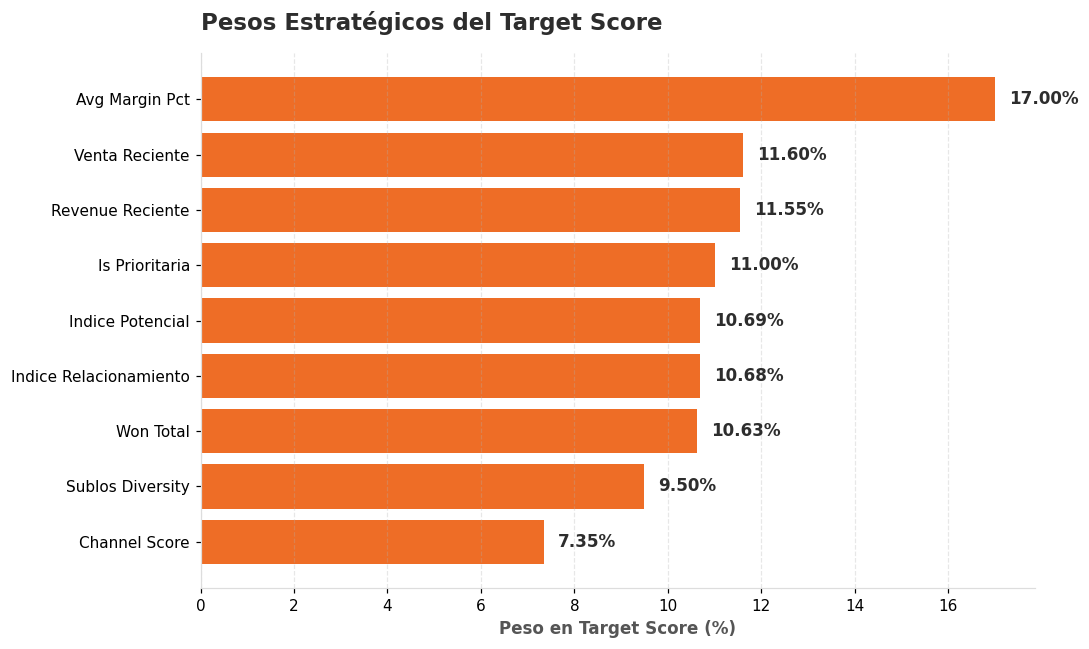

In [6]:
# --- Gráfica: Pesos del Target Score ---

# 1. Ordenamos el diccionario de pesos del mayor al menor
w_items = sorted(feature_weights.items(), key=lambda x: -x[1])

# 2. Limpiamos los nombres técnicos para la presentación (quitamos guiones bajos)
names = [n.replace("_imputed", "").replace("_", " ").title() for n, _ in w_items]

# 3. Convertimos los decimales a porcentajes (ej: 0.17 -> 17.0)
vals = [v * 100 for _, v in w_items]

# 4. Creamos el lienzo
fig, ax = plt.subplots(figsize=(10, 6))

# Usamos [::-1] para invertir la lista y que el peso más grande quede en la parte superior
# Nota: Si ya tienes PWC_ORANGE definido en tu código, puedes cambiar el color="#D93954" por color=PWC_ORANGE
bars = ax.barh(names[::-1], vals[::-1], color="#EB5300", alpha=0.85)

# 5. Agregamos las etiquetas de texto al final de cada barra
for b, v in zip(bars, vals[::-1]):
    ax.text(b.get_width() + 0.3, b.get_y() + b.get_height()/2,
            f"{v:.2f}%",  # Usamos .2f para ver los decimales exactos que ajustamos
            va="center", fontsize=11, fontweight="bold", color="#2D2D2D")

# 6. Formato visual ejecutivo
ax.set_xlabel("Peso en Target Score (%)", fontsize=11, fontweight="bold", color="#555555")
ax.set_title("Pesos Estratégicos del Target Score", fontweight="bold", fontsize=15, loc="left", pad=15, color="#2D2D2D")
ax.grid(alpha=0.3, axis="x", linestyle="--")

# Limpiamos los bordes (spines) para que no parezca un gráfico de Excel antiguo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

plt.tight_layout()
plt.show()

## 5. Target Score (0-100) + K-Means K=5
Clipping P99 sobre features monetarias. StandardScaler. K-Means con `random_state=42`, `n_init=20`.


In [7]:
print("5) Target Score + K-Means K=5...")
X_raw = seg[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values.astype(float)
clip_cols = {'venta_reciente','revenue_reciente','indice_potencial','won_total'}
X_tf = X_raw.copy()
for j, c in enumerate(feature_cols):
    if c in clip_cols:
        p99 = np.percentile(X_raw[:,j], 99)
        X_tf[:,j] = np.clip(X_raw[:,j], 0, p99)
j_mgn = feature_cols.index('avg_margin_pct_imputed')
X_tf[:,j_mgn] = np.clip(X_raw[:,j_mgn], P5, P95)

# Min-max ponderado → score 0-100
mn, mx = X_tf.min(axis=0), X_tf.max(axis=0)
Xmm = (X_tf - mn) / (mx - mn + 1e-9)
w = np.array([feature_weights[c] for c in feature_cols])
seg["Target_Score"] = np.round((Xmm @ w) * 100.0, 2)
print(f"   Target_Score min={seg.Target_Score.min():.1f}  p50={seg.Target_Score.median():.1f}  max={seg.Target_Score.max():.1f}")

# Standardize → KMeans
scaler = StandardScaler()
Xs = scaler.fit_transform(X_tf)
km = KMeans(n_clusters=5, random_state=42, n_init=20)
seg["cluster_id"] = km.fit_predict(Xs)
sil = silhouette_score(Xs, seg["cluster_id"])
print(f"   Silhouette: {sil:.4f}")

# Etiquetar por ranking de Target_Score promedio
prof = seg.groupby("cluster_id").agg(
    n=("PRID","count"), avg_score=("Target_Score","mean"),
    avg_rev=("revenue_reciente","mean"), sum_rev=("revenue_reciente","sum"),
    avg_mgn=("avg_margin_pct_imputed","mean"),
).sort_values("avg_score", ascending=False)
order = prof.index.tolist()
cluster_name_map = {cid: labels_order[i] for i,cid in enumerate(order)}
seg["cluster_name"] = seg["cluster_id"].map(cluster_name_map)
prof["cluster_name"] = [labels_order[i] for i in range(5)]
display(prof)


5) Target Score + K-Means K=5...
   Target_Score min=4.5  p50=21.9  max=89.5
   Silhouette: 0.3730


,n,avg_score,avg_rev,sum_rev,avg_mgn,cluster_name
cluster_id,,,,,,
4,32,64.27,"1,687,698.88","54,006,364.20",0.43,PROTECT & GROW
3,114,48.87,"380,054.39","43,326,200.96",0.46,ACCELERATE
2,211,30.92,"260,484.89","54,962,312.72",0.32,EXPAND
0,135,26.22,"20,197.08","2,726,605.92",0.45,ACTIVATE
1,508,14.56,"15,492.61","7,870,246.81",0.46,QUALIFY


## 6. Churn Risk — 4 factores (escala **0-100**, sin win_rate)

**v7i · Win Rate removido del scoring** (coherente con su eliminación del Target Score en v7f — la trazabilidad de oportunidades LOST no es suficientemente estable para ser un predictor). Los 4 factores restantes se reescalan para que el score máximo posible sea exactamente **100**, no 130.

| Factor | Points |
|---|---|
| Caída ventas FY25 < 0.8 × FY24 | +30 |
| Sin actividad FY25-26 | +25 |
| Margin negativo | +25 |
| Pérdidas recientes >2 (FY25-26) | +20 |
| **Total máximo** | **100** |

**Niveles:** ALERTA ALTA ≥ 50 · ALERTA MEDIA ≥ 30 · MONITOREAR ≥ 1 · ESTABLE = 0
> MEDIA sube de 25 → 30 para que MONITOREAR capture las empresas con una sola señal moderada (sin actividad = 25, margin negativo = 25, o pérdidas recientes = 20) en lugar de colapsar al 1% que producía el esquema anterior.


In [8]:
print("6) Churn risk (4 factores · escala 0-100)...")
seg["_caida_vtas"] = ((seg["Venta FY25 PWC"] < 0.8*seg["Venta FY24 PWC"]) & (seg["Venta FY24 PWC"]>0)).astype(int)*30
seg["_sin_act"]    = (seg["fin_tx_fy25_26"]==0).astype(int)*25
seg["_mgn_neg"]    = (seg["avg_margin_pct_imputed"]<0).astype(int)*25
seg["_lost_rec"]   = ((seg["Oportunidad Lost F25 PWC"]+seg["Oportunidad Lost F26 PWC"])>2).astype(int)*20
seg["churn_risk_score"] = seg[["_caida_vtas","_sin_act","_mgn_neg","_lost_rec"]].sum(axis=1)

def churn_level(s):
    if s>=50: return "ALERTA ALTA"
    if s>=30: return "ALERTA MEDIA"
    if s>=1:  return "MONITOREAR"
    return "ESTABLE"
seg["churn_risk_level"] = seg["churn_risk_score"].apply(churn_level)

print(f"   Score max posible: 30 + 25 + 25 + 20 = 100")
print(f"   Score max observado: {seg['churn_risk_score'].max()}")
display(seg["churn_risk_level"].value_counts().reindex(
    ["ALERTA ALTA","ALERTA MEDIA","MONITOREAR","ESTABLE"]).to_frame("n"))


6) Churn risk (4 factores · escala 0-100)...
   Score max posible: 30 + 25 + 25 + 20 = 100
   Score max observado: 75


,n
churn_risk_level,
ALERTA ALTA,42
ALERTA MEDIA,144
MONITOREAR,458
ESTABLE,356


## 7. Upsell — Gap Analysis P75 (Sub-LoS y Cost Center)
Para cada empresa y cada Sub-LoS no comprada, sumamos el **P75** de revenue del cluster en esa Sub-LoS, multiplicado por **factor de captura 0.5** (asumimos capturar la mitad del gap).


In [9]:
print("7) Upsell P75 gap analysis...")
UPSELL_CAPTURE = 0.5

# --- Sub-LoS ---
sublos_univ = sorted([x for x in fin["Sub-LoS"].dropna().unique() if str(x).strip()!=""])
print(f"   Sub-LoS universo: {len(sublos_univ)}")

rev_piv = (fin[fin["FY_int"].isin([2024,2025,2026])]
           .groupby(["RUC","Sub-LoS"])["Net Revenue"].sum()
           .unstack(fill_value=0)
           .reindex(columns=sublos_univ, fill_value=0))
rev_piv = rev_piv.merge(seg[["RUC","cluster_name"]].set_index("RUC"),
                         left_index=True, right_index=True, how="left")

p75_map = {}
for cl in labels_order:
    p75_map[cl] = {}
    sub = rev_piv[rev_piv["cluster_name"]==cl]
    for sl in sublos_univ:
        positive = sub[sl][sub[sl]>0]
        p75_map[cl][sl] = float(positive.quantile(0.75)) if len(positive)>0 else 0.0

upsell_rev = np.zeros(len(seg))
miss_list  = []
for i, (_, r) in enumerate(seg.iterrows()):
    cl = r["cluster_name"]; ruc = r["RUC"]
    row_rev = rev_piv.loc[ruc] if ruc in rev_piv.index else pd.Series(0, index=sublos_univ)
    miss=[]; gap=0.0
    for sl in sublos_univ:
        if (ruc not in rev_piv.index) or (row_rev[sl]==0):
            miss.append(sl)
            gap += p75_map.get(cl,{}).get(sl,0)*UPSELL_CAPTURE
    upsell_rev[i]=gap; miss_list.append(miss)
seg["upsell_revenue_potential"] = upsell_rev
seg["missing_los"] = miss_list
seg["missing_los_str"] = seg["missing_los"].apply(lambda xs: ", ".join(xs) if xs else "Full coverage")

# --- Cost Center (paralelo) ---
if "Cost Center" in fin.columns:
    cc_univ = sorted([x for x in fin["Cost Center"].dropna().unique() if str(x).strip()!=""])
    print(f"   Cost Center universo: {len(cc_univ)}")
    rev_piv_cc = (fin[fin["FY_int"].isin([2024,2025,2026])]
                  .groupby(["RUC","Cost Center"])["Net Revenue"].sum()
                  .unstack(fill_value=0).reindex(columns=cc_univ, fill_value=0))
    rev_piv_cc = rev_piv_cc.merge(seg[["RUC","cluster_name"]].set_index("RUC"),
                                   left_index=True, right_index=True, how="left")
    p75_cc = {}
    for cl in labels_order:
        p75_cc[cl] = {}
        sub = rev_piv_cc[rev_piv_cc["cluster_name"]==cl]
        for cc in cc_univ:
            positive = sub[cc][sub[cc]>0]
            p75_cc[cl][cc] = float(positive.quantile(0.75)) if len(positive)>0 else 0.0

    upsell_cc = np.zeros(len(seg)); miss_cc=[]
    for i, (_, r) in enumerate(seg.iterrows()):
        cl=r["cluster_name"]; ruc=r["RUC"]
        row_rev = rev_piv_cc.loc[ruc] if ruc in rev_piv_cc.index else pd.Series(0,index=cc_univ)
        m=[]; g=0.0
        for cc in cc_univ:
            if (ruc not in rev_piv_cc.index) or (row_rev[cc]==0):
                m.append(cc)
                g += p75_cc.get(cl,{}).get(cc,0)*UPSELL_CAPTURE
        upsell_cc[i]=g; miss_cc.append(m)
    seg["upsell_revenue_potential_cc"]=upsell_cc
    seg["missing_cc"]=miss_cc

# Margin promedio del cluster para upsell margin potential
cluster_mgn = seg.groupby("cluster_name")["avg_margin_pct_imputed"].mean().to_dict()
seg["upsell_margin_potential"] = seg.apply(
    lambda r: r["upsell_revenue_potential"] * max(cluster_mgn.get(r["cluster_name"],0.35), 0.05), axis=1)

print(f"\n   Upsell total Sub-LoS:    S/.{seg['upsell_revenue_potential'].sum()/1e6:.1f}M")
if "upsell_revenue_potential_cc" in seg.columns:
    print(f"   Upsell total Cost Center: S/.{seg['upsell_revenue_potential_cc'].sum()/1e6:.1f}M")


7) Upsell P75 gap analysis...
   Sub-LoS universo: 11
   Cost Center universo: 23

   Upsell total Sub-LoS:    S/.510.7M
   Upsell total Cost Center: S/.900.1M


## 8. Riesgo Basel II — EL · Monte Carlo VaR(95%) · CVaR(95%) · NRAO · Inconsistencia

**Modelo de cartera de ingresos (estilo Basel-II):**
- **Expected Loss (EL):**  `EL_i = EAD_i × PD_i`  con `EAD = revenue_reciente`, `PD = churn_risk_score / 100`.
- **VaR(95%) Monte Carlo:** 10,000 escenarios. En cada escenario tiramos `Bernoulli(p=PD_i)` por empresa; pérdida del escenario = Σ EAD × default. **VaR_95 = percentil 95** de las pérdidas simuladas.
- **CVaR(95%):** promedio de pérdidas ≥ VaR_95 (Expected Shortfall).
- **NRAO (Net Risk-Adjusted Opportunity):** `upsell − EL` por empresa.
- **Flag de Inconsistencia:** `Target_Score ≥ P75` AND `Venta FY25 < Venta FY24` AND `Venta FY24 > 0` → "Score alto · tendencia en caída".


In [10]:
print("8) Riesgo Basel II...")

# --- Expected Loss por empresa
seg["PD"]  = np.clip(seg["churn_risk_score"]/100.0, 0.0, 1.0)
seg["EAD"] = seg["revenue_reciente"]
seg["EL_empresa"] = seg["EAD"] * seg["PD"]
EL_book = float(seg["EL_empresa"].sum())

# --- Monte Carlo VaR(95%) y CVaR(95%)
rng = np.random.default_rng(seed=42)
N_SIM = 10_000
pd_vec  = seg["PD"].values
ead_vec = seg["EAD"].values
sim_def = (rng.random((N_SIM, len(seg))) < pd_vec).astype(np.float32)
sim_losses = sim_def @ ead_vec.astype(np.float32)
VaR_95  = float(np.percentile(sim_losses, 95))
CVaR_95 = float(sim_losses[sim_losses >= VaR_95].mean())
EL_mc   = float(sim_losses.mean())


seg["EL_margin"] = seg["EL_empresa"] * seg["avg_margin_pct_imputed"]
# --- NRAO
seg["NRAO"] = seg["upsell_margin_potential"] - seg["EL_margin"]

# --- Flag inconsistencia
p75_score = seg["Target_Score"].quantile(0.75)
seg["venta_delta_24_25"] = seg["Venta FY25 PWC"] - seg["Venta FY24 PWC"]
seg["inconsistency_flag"] = (
    (seg["Target_Score"] >= p75_score) &
    (seg["venta_delta_24_25"] < 0) &
    (seg["Venta FY24 PWC"] > 0)
).astype(int)

# --- Métricas resumen
risk_metrics = {
    "EL_book_total": EL_book,
    "MC_EL_sim":     EL_mc,
    "MC_VaR_95":     VaR_95,
    "MC_CVaR_95":    CVaR_95,
    "MC_loss_min":   float(sim_losses.min()),
    "MC_loss_max":   float(sim_losses.max()),
    "MC_loss_std":   float(sim_losses.std()),
    "NRAO_Margin_total":          float(seg["NRAO"].sum()),
    "NRAO_positive_n":     int((seg["NRAO"]>0).sum()),
    "NRAO_negative_n":     int((seg["NRAO"]<0).sum()),
    "inconsistency_n":     int(seg["inconsistency_flag"].sum()),
    "p75_target_score":    float(p75_score),
}
for k,v in risk_metrics.items():
    if isinstance(v,(int,np.integer)): print(f"   {k:25s}: {v:,}")
    else: print(f"   {k:25s}: S/.{v/1e6:>8.2f}M" if abs(v)>1e3 else f"   {k:25s}: {v:.4f}")

# Tabla por cluster (Actualizada para la visión del Director)
risk_by_cluster = pd.DataFrame([{
    "cluster": cl,
    "n": int((seg["cluster_name"]==cl).sum()),
    "EL_Revenue_M": seg.loc[seg["cluster_name"]==cl,"EL_empresa"].sum()/1e6,
    "EL_Margin_M": seg.loc[seg["cluster_name"]==cl,"EL_margin"].sum()/1e6,               # <-- Nuevo: Riesgo de Utilidad
    "Upsell_Margin_M": seg.loc[seg["cluster_name"]==cl,"upsell_margin_potential"].sum()/1e6, # <-- Nuevo: Utilidad Nueva
    "NRAO_Margin_M": seg.loc[seg["cluster_name"]==cl,"NRAO"].sum()/1e6,                  # <-- Nuevo: Utilidad Neta Real
    "inconsistency_n": int(seg.loc[seg["cluster_name"]==cl,"inconsistency_flag"].sum()),
} for cl in labels_order])
display(risk_by_cluster)


8) Riesgo Basel II...
   EL_book_total            : S/.   10.73M
   MC_EL_sim                : S/.   10.71M
   MC_VaR_95                : S/.   14.60M
   MC_CVaR_95               : S/.   15.67M
   MC_loss_min              : S/.    3.15M
   MC_loss_max              : S/.   20.05M
   MC_loss_std              : S/.    2.27M
   NRAO_Margin_total        : S/.  214.71M
   NRAO_positive_n          : 1,000
   NRAO_negative_n          : 0
   inconsistency_n          : 104
   p75_target_score         : 32.0475


,cluster,n,EL_Revenue_M,EL_Margin_M,Upsell_Margin_M,NRAO_Margin_M,inconsistency_n
0,PROTECT & GROW,32,3.57,1.43,27.99,26.56,12
1,ACCELERATE,114,2.24,1.02,34.50,33.48,47
2,EXPAND,211,3.82,1.42,27.00,25.58,34
3,ACTIVATE,135,0.40,0.21,20.01,19.80,11
4,QUALIFY,508,0.70,0.36,109.64,109.29,0


## 8b. Risk Analytics — vista ejecutiva (VaR determinista · CVaR top 5% score · NRAO · Tracking Error)

> **Complemento al Basel II de 8.** La vista Basel II (EL + Monte Carlo) es la correcta para reporting financiero **probabilístico**; pero para conversación con líderes de negocio se usa una formulación **determinista** más directa, que es la que tú planteaste:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **VaR por empresa** | `VaR_i = Revenue_i × (churn_score_i / 100)` | Pérdida esperada si la fuga se materializa (= EL de Basel II). Determinista, lineal. |
| **CVaR (top 5% score)** | `mean(VaR_i)` para el 5% con peor score | Pérdida promedio en el peor cuantil por *score de riesgo*. **NO** simula escenarios, tranca en las empresas más riesgosas del book. |
| **NRAO** | `upsell_revenue_potential_i − VaR_i` | Si el potencial de upsell compensa la pérdida esperada. Positivo = crecer; Negativo = retener antes de invertir. |
| **Tracking Error** | Flag "Desviación de Modelo": `Target_Score ≥ P75` **AND** `Venta FY25 < Venta FY24` | El modelo dice "alta prioridad" pero el negocio real está cayendo → revisión del dato o del criterio de scoring. |

**Diferencia clave vs Basel II:**
- **Basel II CVaR (MC):** simula 10K escenarios Bernoulli; recoge la cola de pérdidas conjuntas.
- **CVaR Alvaro:** no simula; es el promedio determinista del peor 5% por *score*, útil cuando quieres decir *"estas son las N cuentas más tóxicas"*.

Ambas conviven porque responden preguntas distintas: la MC habla de *portfolio risk*, la determinista habla de *top offenders*.


In [11]:
print("8b) Risk Analytics · vista determinista ejecutiva...")

# --- 1) VaR por empresa (= EL Basel II, renombrado a VaR_Revenue)
seg["VaR_Revenue"] = seg["revenue_reciente"] * (seg["churn_risk_score"] / 100.0)

# --- 2) CVaR top 5% score — promedio del VaR en las empresas con peor churn_score
alta = seg[seg["churn_risk_level"]=="ALERTA ALTA"].copy()
cvar_cutoff = int(max(1, np.ceil(len(alta)*0.05))) if len(alta)>0 else 0

# Dos vistas: top 5% del universo ALERTA ALTA, y top 5% del book completo
top5_alta  = alta.nlargest(cvar_cutoff, "churn_risk_score") if cvar_cutoff>0 else alta.head(0)
cvar_alta_M = top5_alta["VaR_Revenue"].mean()/1e6 if len(top5_alta)>0 else 0.0

top5_book  = seg.nlargest(max(1,int(np.ceil(len(seg)*0.05))), "churn_risk_score")
cvar_book_M = top5_book["VaR_Revenue"].mean()/1e6
cvar_book_sum_M = top5_book["VaR_Revenue"].sum()/1e6

# --- 3) Net Risk-Adjusted Opportunity (determinista, por empresa)
# Paso A: Convertir la Exposición de Ingresos a Exposición de Margen
seg["VaR_Margin"] = seg["VaR_Revenue"] * seg["avg_margin_pct_imputed"]

# Paso B: Calcular el NRAO Apples-to-Apples (Margen Upsell vs Margen en Riesgo)
seg["NRAO_det"] = seg["upsell_margin_potential"] - seg["VaR_Margin"]

# Resumen de métricas
nrao_positive_n = int((seg["NRAO_det"]>0).sum())
nrao_total_M = seg["NRAO_det"].sum()/1e6

# --- 4) Tracking Error / Desviación de Modelo
# Regla: Target_Score alto (>=P75) + venta_reciente cayendo (FY25 < FY24) + FY24 > 0
p75_ts = seg["Target_Score"].quantile(0.75)
seg["venta_falling"]       = ((seg["Venta FY25 PWC"] < seg["Venta FY24 PWC"]) & (seg["Venta FY24 PWC"]>0)).astype(int)
seg["desviacion_modelo"]   = ((seg["Target_Score"]>=p75_ts) & (seg["venta_falling"]==1)).astype(int)
desviacion_n     = int(seg["desviacion_modelo"].sum())
desviacion_rev_M = seg.loc[seg["desviacion_modelo"]==1,"revenue_reciente"].sum()/1e6

print(f"   VaR total book:         S/.{seg['VaR_Revenue'].sum()/1e6:,.2f}M")
print(f"   VaR promedio por empresa: S/.{seg['VaR_Revenue'].mean()/1e3:,.1f}K")
print(f"   CVaR top 5% ALERTA ALTA: S/.{cvar_alta_M:,.2f}M (promedio por empresa, n={cvar_cutoff})")
print(f"   CVaR top 5% book:       S/.{cvar_book_M:,.2f}M promedio | S/.{cvar_book_sum_M:,.2f}M suma")
print(f"   NRAO (Margen Neto Ajustado): S/.{nrao_total_M:,.2f}M ({nrao_positive_n} empresas con NRAO>0)")
print(f"   Desviación de Modelo:   {desviacion_n} empresas flagueadas (S/.{desviacion_rev_M:,.1f}M en revenue)")

# Tabla ejecutiva por cluster (Ajustada para que el Director vea la resta perfecta de Márgenes)
risk_alvaro = pd.DataFrame([{
    "cluster": cl,
    "n": int((seg["cluster_name"]==cl).sum()),
    "Revenue_M":      seg.loc[seg["cluster_name"]==cl,"revenue_reciente"].sum()/1e6,
    "VaR_Rev_M":      seg.loc[seg["cluster_name"]==cl,"VaR_Revenue"].sum()/1e6,
    "VaR_Margin_M":   seg.loc[seg["cluster_name"]==cl,"VaR_Margin"].sum()/1e6,                 # <-- El Riesgo en Margen
    "Upsell_Margin_M":seg.loc[seg["cluster_name"]==cl,"upsell_margin_potential"].sum()/1e6,    # <-- El Upsell en Margen
    "NRAO_det_M":     seg.loc[seg["cluster_name"]==cl,"NRAO_det"].sum()/1e6,                   # <-- El Neto en Margen
    "Desv_Modelo_n":  int(seg.loc[seg["cluster_name"]==cl,"desviacion_modelo"].sum()),
} for cl in labels_order])

risk_alvaro["Recomendacion"] = np.where(risk_alvaro["NRAO_det_M"]>0, "CRECER", "RETENER PRIMERO")

ra_show = risk_alvaro.copy()
# Formateamos todas las columnas monetarias
for c in ["Revenue_M", "VaR_Rev_M", "VaR_Margin_M", "Upsell_Margin_M", "NRAO_det_M"]:
    ra_show[c] = ra_show[c].map(lambda v: f"S/.{v:.1f}M")

display(ra_show)

# Top 10 "Desviación de Modelo" (para revisión caso-a-caso)
print("\nTop 10 empresas con Desviación de Modelo (Target alto + venta cayendo):")
desv_top = seg[seg["desviacion_modelo"]==1].nlargest(10, "revenue_reciente")[[
    "RUC","razon_social","cluster_name","Target_Score",
    "Venta FY24 PWC","Venta FY25 PWC","revenue_reciente","VaR_Revenue"
]].copy()
for c in ["Venta FY24 PWC","Venta FY25 PWC","revenue_reciente","VaR_Revenue"]:
    desv_top[c] = desv_top[c].map(lambda v: f"S/.{v:,.0f}")
desv_top["Target_Score"] = desv_top["Target_Score"].map(lambda v: f"{v:.0f}")
display(desv_top)

risk_alvaro_summary = {
    "VaR_book_total_M":      seg["VaR_Revenue"].sum()/1e6,
    "CVaR_top5_alta_M":      cvar_alta_M,
    "CVaR_top5_book_M":      cvar_book_M,
    "NRAO_det_total_M":      nrao_total_M,
    "NRAO_positive_n":       nrao_positive_n,
    "desviacion_modelo_n":   desviacion_n,
    "desviacion_revenue_M":  desviacion_rev_M,
    "p75_target_score":      float(p75_ts),
}


8b) Risk Analytics · vista determinista ejecutiva...
   VaR total book:         S/.10.73M
   VaR promedio por empresa: S/.10.7K
   CVaR top 5% ALERTA ALTA: S/.0.00M (promedio por empresa, n=3)
   CVaR top 5% book:       S/.0.01M promedio | S/.0.50M suma
   NRAO (Margen Neto Ajustado): S/.214.71M (1000 empresas con NRAO>0)
   Desviación de Modelo:   104 empresas flagueadas (S/.46.5M en revenue)


,cluster,n,Revenue_M,VaR_Rev_M,VaR_Margin_M,Upsell_Margin_M,NRAO_det_M,Desv_Modelo_n,Recomendacion
0,PROTECT & GROW,32,S/.54.0M,S/.3.6M,S/.1.4M,S/.28.0M,S/.26.6M,12,CRECER
1,ACCELERATE,114,S/.43.3M,S/.2.2M,S/.1.0M,S/.34.5M,S/.33.5M,47,CRECER
2,EXPAND,211,S/.55.0M,S/.3.8M,S/.1.4M,S/.27.0M,S/.25.6M,34,CRECER
3,ACTIVATE,135,S/.2.7M,S/.0.4M,S/.0.2M,S/.20.0M,S/.19.8M,11,CRECER
4,QUALIFY,508,S/.7.9M,S/.0.7M,S/.0.4M,S/.109.6M,S/.109.3M,0,CRECER



Top 10 empresas con Desviación de Modelo (Target alto + venta cayendo):


,RUC,razon_social,cluster_name,Target_Score,Venta FY24 PWC,Venta FY25 PWC,revenue_reciente,VaR_Revenue
35,20331898008,LUZ DEL SUR S.A.A.,PROTECT & GROW,75,"S/.1,076,326","S/.1,061,482","S/.3,230,744",S/.0
0,20100047218,BANCO DE CREDITO DEL PERU,PROTECT & GROW,87,"S/.2,018,457","S/.1,440,712","S/.2,134,606","S/.640,382"
64,20333363900,ENGIE ENERGIA PERU S.A.A.,PROTECT & GROW,60,"S/.1,149,100","S/.892,137","S/.1,673,568","S/.502,070"
50,20261677955,NEXA RESOURCES CAJAMARQUILLA S.A.,PROTECT & GROW,56,"S/.781,725","S/.714,743","S/.1,337,525",S/.0
23,20100055237,ALICORP S.A.A.,PROTECT & GROW,69,"S/.1,936,908","S/.1,021,968","S/.1,275,102","S/.382,530"
229,20330791501,QUIMPAC S.A.,PROTECT & GROW,75,"S/.1,239,825","S/.910,401","S/.1,249,779","S/.374,934"
191,20215276024,UNIVERSIDAD PRIVADA DEL NORTE S.A.C.,EXPAND,36,"S/.577,371","S/.514,489","S/.1,088,645",S/.0
422,20122476309,BANCO CENTRAL DE RESERVA DEL PERU,PROTECT & GROW,43,"S/.1,113,561","S/.1,075,586","S/.1,075,586","S/.215,117"
146,20513320915,SAN MIGUEL INDUSTRIAS PET S.A.,PROTECT & GROW,51,"S/.783,854","S/.516,580","S/.1,036,411","S/.310,923"
431,20100137390,UNACEM CORP S.A.A.,PROTECT & GROW,65,"S/.1,830,193","S/.918,202","S/.1,028,656","S/.308,597"


### Gráfica 5b · VaR vs Upsell por cluster — ¿dónde crecer vs dónde retener?
Barras contrapuestas: **naranja = VaR (riesgo monetario)**, **azul = Upsell (oportunidad)**. Si el naranja es más largo que el azul, **hay que retener antes de invertir en crecer**. Los ejes son directamente S/. millones, no percentiles — perfecto para conversación con C-suite.


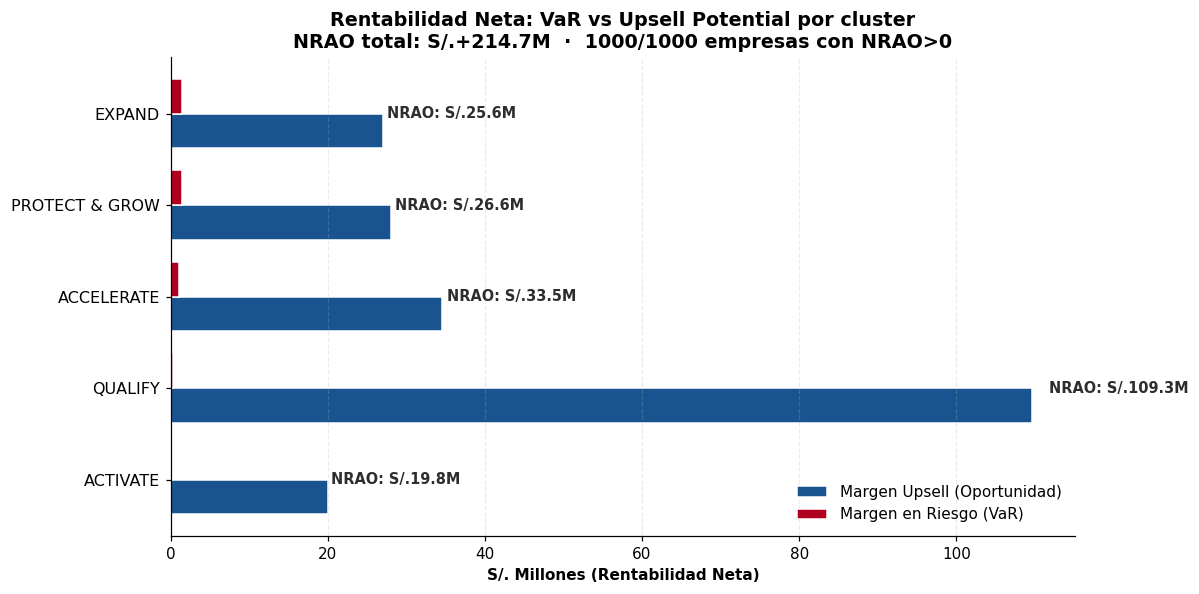

In [40]:
ra = risk_alvaro.sort_values("Revenue_M")
fig, ax = plt.subplots(figsize=(11,5.5))
y = np.arange(len(ra)); h = 0.38

# Barras Margen vs Margen (estilo visual idéntico a la sección 8)
ax.barh(y-h/2, ra["Upsell_Margin_M"], height=h, color=PWC_BLUE,   edgecolor="white", label="Margen Upsell (Oportunidad)")
ax.barh(y+h/2, ra["VaR_Margin_M"],    height=h, color="#B00020",  edgecolor="white", label="Margen en Riesgo (VaR)")

ax.set_yticks(y); ax.set_yticklabels(ra["cluster"], fontsize=10.5)
ax.set_xlabel("S/. Millones (Rentabilidad Neta)", fontweight="bold")

ax.set_title(f"Rentabilidad Neta: VaR vs Upsell Potential por cluster\n"
             f"NRAO total: S/.{ra['NRAO_det_M'].sum():+.1f}M  ·  {nrao_positive_n}/{len(seg)} empresas con NRAO>0",
             fontweight="bold", fontsize=12.5)

# Textos alineados a la derecha mostrando el NRAO neto (Igual que en la sec 8)
for i, (idx, r) in enumerate(ra.iterrows()):
    ax.text(max(r["Upsell_Margin_M"], r["VaR_Margin_M"])*1.02, i, f"NRAO: S/.{r['NRAO_det_M']:.1f}M",
            va="center", fontsize=9.5, fontweight="bold", color=PWC_DARK)

ax.legend(loc="lower right", frameon=False, fontsize=10)
ax.grid(alpha=0.25, axis="x", linestyle="--")
ax.axvline(0, color="black", linewidth=0.6)
plt.tight_layout(); plt.show()

## 9. KPIs ejecutivos del book


In [13]:
kpis = {
    "n_empresas": int(len(seg)),
    "revenue_total_book":      seg["revenue_reciente"].sum()/1e6,
    "margin_promedio_book":    seg["avg_margin_pct_imputed"].mean(),
    "target_score_promedio":   seg["Target_Score"].mean(),
    "n_prioritarias":          int(seg["is_prioritaria"].sum()),
    "churn_alta":              int((seg["churn_risk_level"]=="ALERTA ALTA").sum()),
    "churn_media":             int((seg["churn_risk_level"]=="ALERTA MEDIA").sum()),
    "churn_monit":             int((seg["churn_risk_level"]=="MONITOREAR").sum()),
    "churn_estable":           int((seg["churn_risk_level"]=="ESTABLE").sum()),
    "revenue_en_riesgo_M":     seg[seg["churn_risk_level"].isin(["ALERTA ALTA","ALERTA MEDIA"])]["revenue_reciente"].sum()/1e6,
    "upsell_total_rev_M":      seg["upsell_revenue_potential"].sum()/1e6,
    "EL_book_M":               EL_book/1e6,
    "VaR_95_M":                VaR_95/1e6,
    "CVaR_95_M":               CVaR_95/1e6,
    "NRAO_total_M":            seg["NRAO"].sum()/1e6,
    "VaR_book_total_M":        seg["VaR_Revenue"].sum()/1e6,
    "CVaR_top5_alta_M":        risk_alvaro_summary["CVaR_top5_alta_M"],
    "NRAO_det_total_M":        risk_alvaro_summary["NRAO_det_total_M"],
    "desviacion_modelo_n":     risk_alvaro_summary["desviacion_modelo_n"],
    "silhouette":              sil,
}
display(pd.DataFrame.from_dict(kpis, orient="index", columns=["valor"]))


,valor
n_empresas,"1,000.00"
revenue_total_book,162.89
margin_promedio_book,0.43
target_score_promedio,25.09
n_prioritarias,266.00
churn_alta,42.00
churn_media,144.00
churn_monit,458.00
churn_estable,356.00
revenue_en_riesgo_M,30.46


## 10. Resumen por cluster


In [14]:
cluster_summary = pd.DataFrame([{
    "cluster":        cl,
    "verbo":          verbs[cl],
    "n":              int((seg["cluster_name"]==cl).sum()),
    "revenue_M":      seg.loc[seg["cluster_name"]==cl,"revenue_reciente"].sum()/1e6,
    "avg_score":      seg.loc[seg["cluster_name"]==cl,"Target_Score"].mean(),
    "avg_margin":     seg.loc[seg["cluster_name"]==cl,"avg_margin_pct_imputed"].mean(),
    "n_alta":         int((seg.loc[seg["cluster_name"]==cl,"churn_risk_level"]=="ALERTA ALTA").sum()),
    "n_media":        int((seg.loc[seg["cluster_name"]==cl,"churn_risk_level"]=="ALERTA MEDIA").sum()),
    "upsell_M":       seg.loc[seg["cluster_name"]==cl,"upsell_revenue_potential"].sum()/1e6,
    "EL_M":           seg.loc[seg["cluster_name"]==cl,"EL_empresa"].sum()/1e6,
    "pct_prioritarias": seg.loc[seg["cluster_name"]==cl,"is_prioritaria"].mean(),
} for cl in labels_order])
display(cluster_summary)


,cluster,verbo,n,revenue_M,avg_score,avg_margin,n_alta,n_media,upsell_M,EL_M,pct_prioritarias
0,PROTECT & GROW,DEFENDER,32,54.01,64.27,0.43,0,8,65.74,3.57,0.44
1,ACCELERATE,ESCALAR,114,43.33,48.87,0.46,1,24,75.31,2.24,0.49
2,EXPAND,AMPLIAR,211,54.96,30.92,0.32,4,49,85.48,3.82,0.29
3,ACTIVATE,ACTIVAR,135,2.73,26.22,0.45,9,21,44.70,0.40,1.00
4,QUALIFY,FILTRAR,508,7.87,14.56,0.46,28,42,239.46,0.70,0.00


---
# VISUALIZACIONES (todas inline)


### Gráfica 1 · Clusters en espacio PCA 2D


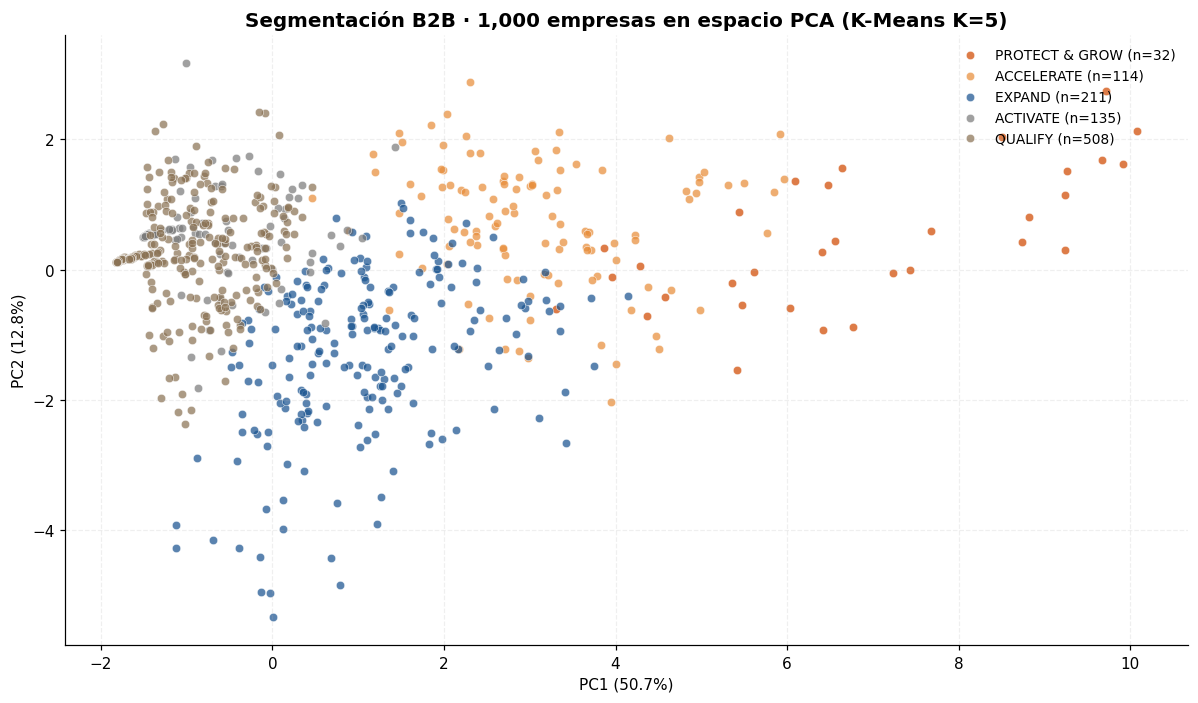

In [15]:
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xs)
fig, ax = plt.subplots(figsize=(11,6.5))
for cl in labels_order:
    mask = seg["cluster_name"]==cl
    ax.scatter(Z[mask,0], Z[mask,1], s=30, alpha=0.72, color=CL_COLORS[cl],
               label=f"{cl} (n={mask.sum()})", edgecolor="white", linewidth=0.4)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Segmentación B2B · 1,000 empresas en espacio PCA (K-Means K=5)", fontweight="bold")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.grid(alpha=0.2, linestyle="--")
plt.tight_layout(); plt.show()


### Gráfica 2 · Distribución del Target Score por segmento


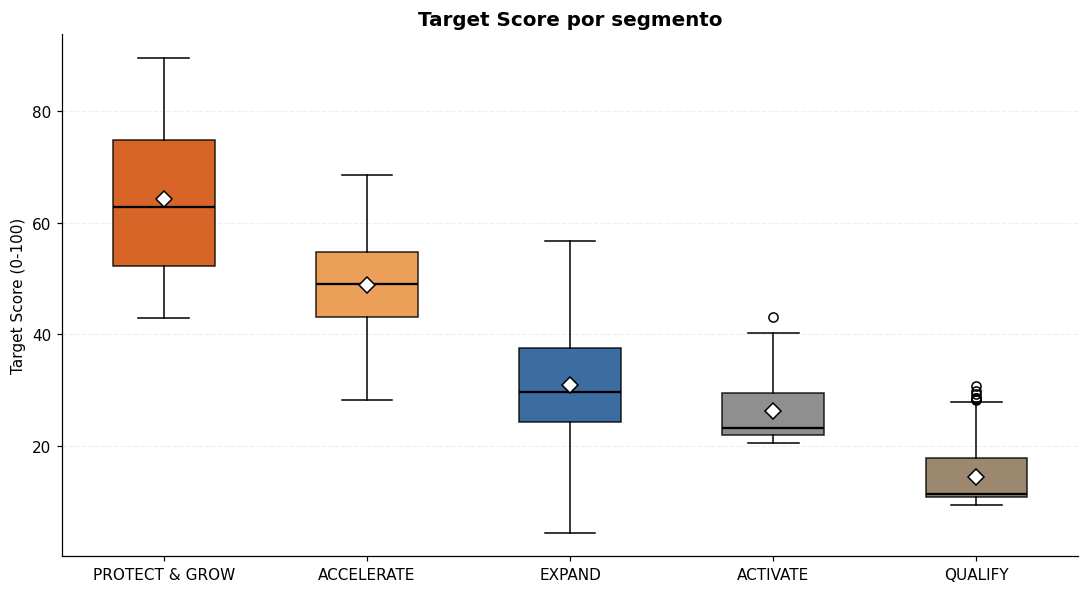

In [16]:
fig, ax = plt.subplots(figsize=(10,5.5))
data = [seg[seg["cluster_name"]==cl]["Target_Score"].values for cl in labels_order]
bp = ax.boxplot(data, labels=labels_order, patch_artist=True, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=7),
                medianprops=dict(color="black", linewidth=1.5))
for patch, cl in zip(bp["boxes"], labels_order):
    patch.set_facecolor(CL_COLORS[cl]); patch.set_alpha(0.85)
ax.set_ylabel("Target Score (0-100)")
ax.set_title("Target Score por segmento", fontweight="bold")
ax.grid(alpha=0.2, axis="y", linestyle="--")
plt.tight_layout(); plt.show()


### Gráfica 3 · Radar de perfil multidimensional (9 variables del Target Score)
Agrupadas en **Monetary** (Revenue, Venta, Margin), **Strategic** (% Prioritaria, Potencial, Canal), **Activity** (WON, Sub-LoS, Relación).

**v7i — Normalización cambiada a PERCENTIL DEL BOOK.** Cada valor en el radar representa *"qué porcentaje de empresas del book están por debajo del promedio del cluster en esa variable"*. Por ejemplo, 0.90 en Revenue significa que el 90% de empresas del book tienen menos revenue que la empresa promedio de ese cluster. Esto da magnitudes **reales y comparables** en lugar de la normalización anterior por "máximo entre cluster-means" (que inflaba al líder a 100% automáticamente y comprimía los demás al centro).


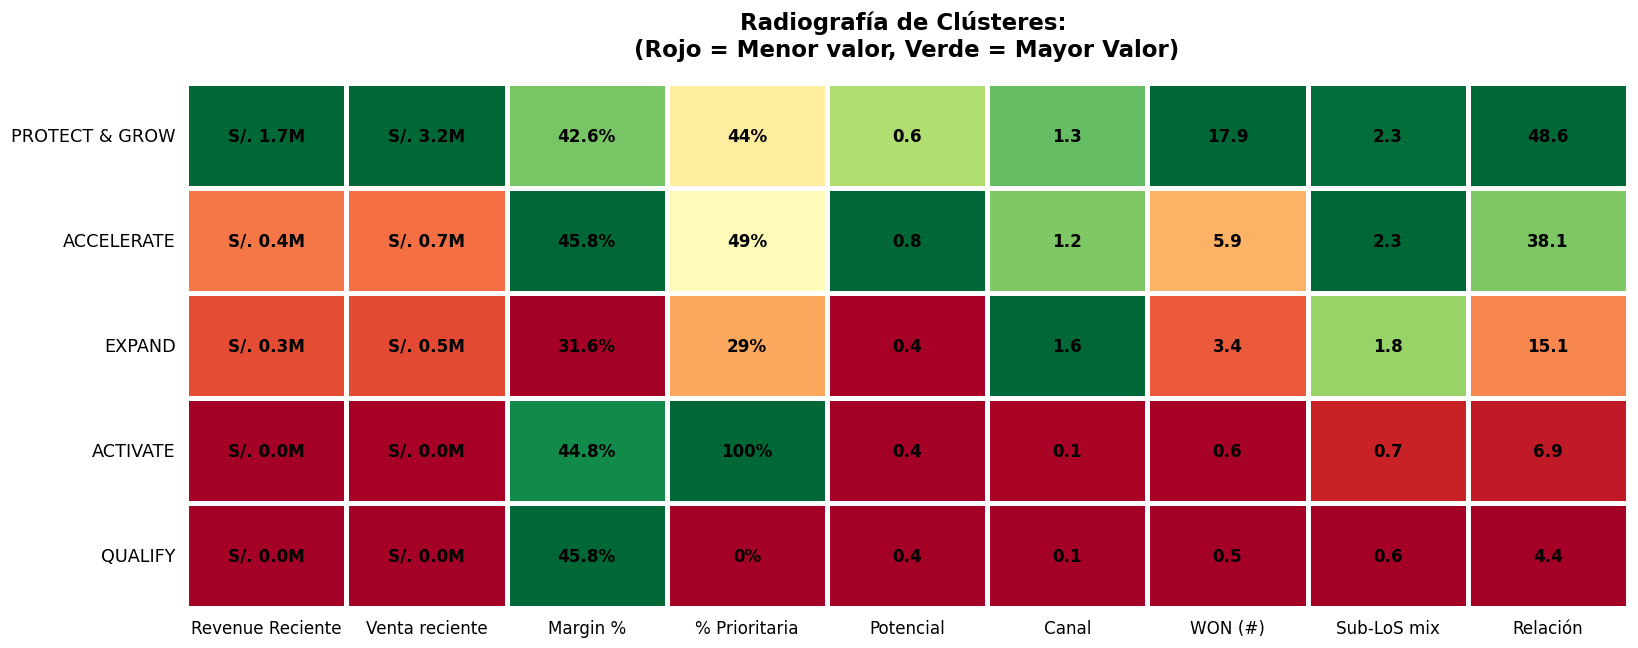

In [17]:
# 1. Las variables y etiquetas actualizadas
import seaborn as sns
radar_dims = [
    'revenue_reciente','venta_reciente','avg_margin_pct_imputed',
    'is_prioritaria','indice_potencial','channel_score',
    'won_total','sublos_diversity','indice_relacionamiento',
]
radar_labels = ['Revenue Reciente','Venta reciente','Margin %',
                '% Prioritaria','Potencial','Canal',
                'WON (#)','Sub-LoS mix','Relación']

# 2. Calculamos los promedios reales (numéricos puros)
abs_means = seg.groupby("cluster_name")[radar_dims].mean().reindex(labels_order)

# 3. Diccionario de formateo ejecutivo (los textos que irán dentro de los cuadraditos)
fmt_dict = {
    'revenue_reciente': lambda x: f"S/. {x/1e6:.1f}M",
    'venta_reciente': lambda x: f"S/. {x/1e6:.1f}M",
    'avg_margin_pct_imputed': lambda x: f"{x*100:.1f}%",
    'is_prioritaria': lambda x: f"{x*100:.0f}%",
    'indice_potencial': lambda x: f"{x:.1f}",
    'channel_score': lambda x: f"{x:.1f}",
    'won_total': lambda x: f"{x:.1f}",
    'sublos_diversity': lambda x: f"{x:.1f}",
    'indice_relacionamiento': lambda x: f"{x:.1f}"
}

# 4. Creamos la tabla de Textos aplicando el formato
tabla_text = abs_means.copy()
for col, formatter in fmt_dict.items():
    if col in tabla_text.columns:
        tabla_text[col] = tabla_text[col].map(formatter)
tabla_text.columns = radar_labels

# 5. Normalizamos matemáticamente (SOLO para que el mapa sepa qué pintar más oscuro por cada columna)
abs_means_norm = (abs_means - abs_means.min()) / (abs_means.max() - abs_means.min())
abs_means_norm.columns = radar_labels

# 6. Dibujamos el Heatmap (Mapa de Calor)
# CAMBIO DE TAMAÑO: Aumentamos de (13, 4.5) a (15, 6) para que ocupe bien la pantalla
fig, ax = plt.subplots(figsize=(15, 6))

# CAMBIO DE COLOR: Usamos "RdYlGn" (Rojo -> Amarillo -> Verde)
sns.heatmap(abs_means_norm, annot=tabla_text, fmt="", cmap="RdYlGn",
            cbar=False, linewidths=2, linecolor='white', ax=ax,
            annot_kws={"fontsize": 11, "fontweight": "bold", "color":"black"})

ax.set_title("Radiografía de Clústeres: \n(Rojo = Menor valor, Verde = Mayor Valor)",
             fontsize=15, fontweight="bold", pad=18)
ax.set_ylabel("") # Quitamos la etiqueta del eje Y para que se vea más limpio
ax.tick_params(axis='x', labelsize=11, labelcolor="black", bottom=False)
ax.tick_params(axis='y', labelsize=11.5, labelcolor="black", left=False)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Gráfica 4 · Matriz ejecutiva semáforo — Churn × Upsell × Acción


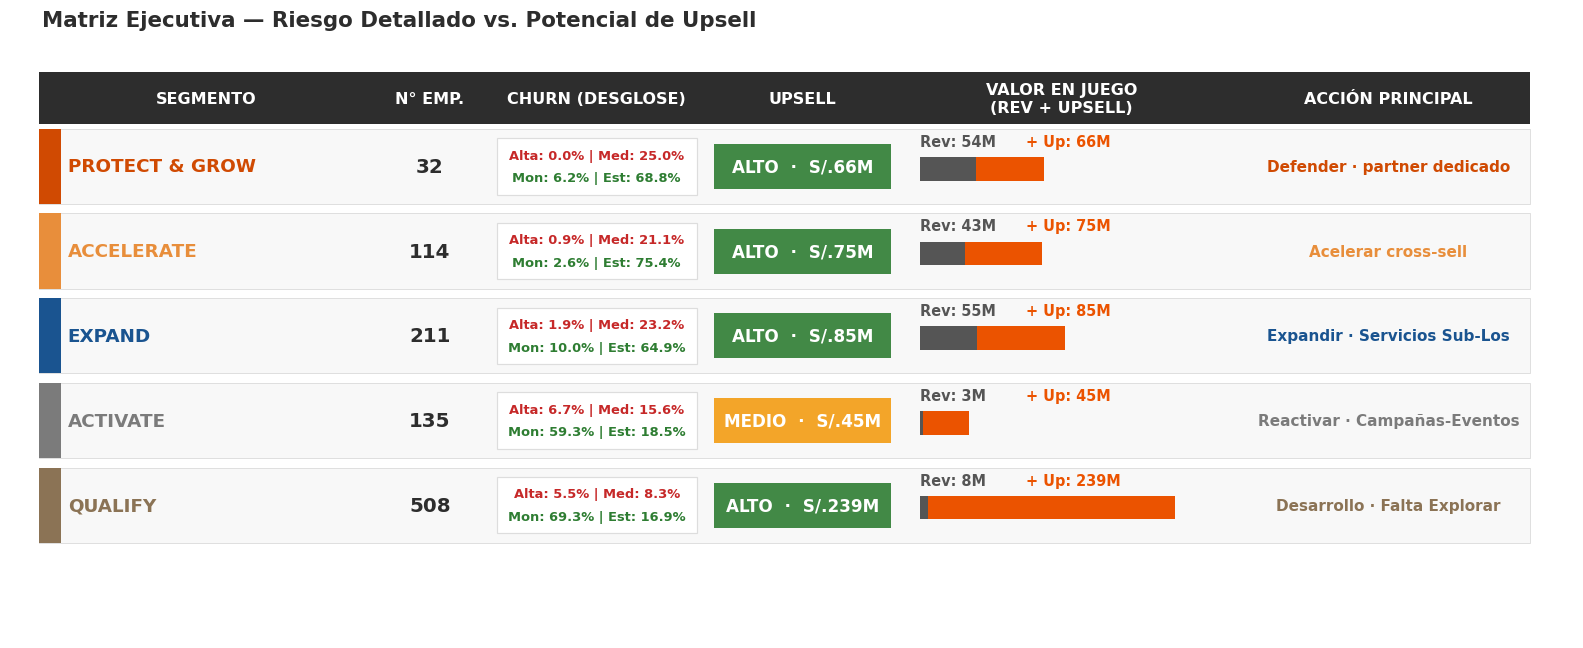

In [18]:
# --- MATRIZ EJECUTIVA (Con desglose completo de 4 niveles de Churn) ---

# 1. Agrupación Base
agg = seg.groupby("cluster_name").agg(
    n=("razon_social","count"),
    upsell_total=("upsell_revenue_potential","sum"),
    rev=("revenue_reciente","sum"),
    prio=("is_prioritaria","mean"),
).reindex(labels_order).reset_index()

# 2. NUEVO: Calculamos los 4 niveles de riesgo y los unimos a 'agg'
churn_data = []
for cl in labels_order:
    c_data = seg[seg["cluster_name"] == cl]
    n_div = max(1, len(c_data))
    churn_data.append({
        "cluster_name": cl,
        "pct_alta": (c_data["churn_risk_level"] == "ALERTA ALTA").sum() / n_div * 100,
        "pct_media": (c_data["churn_risk_level"] == "ALERTA MEDIA").sum() / n_div * 100,
        "pct_monit": (c_data["churn_risk_level"] == "MONITOREAR").sum() / n_div * 100,
        "pct_estab": (c_data["churn_risk_level"] == "ESTABLE").sum() / n_div * 100
    })
agg = agg.merge(pd.DataFrame(churn_data), on="cluster_name")

# 3. Semáforo para Upsell (Mantenemos el tuyo)
def _sem_upsell(up_m):
    if up_m >= 60: return "#2E7D32","ALTO"
    if up_m >= 20: return "#F39C12","MEDIO"
    return "#9E9E9E","BAJO"

action = {
    "PROTECT & GROW":"Defender · partner dedicado",
    "ACCELERATE":"Acelerar cross-sell",
    "EXPAND":"Expandir · Servicios Sub-Los",
    "ACTIVATE":"Reactivar · Campañas-Eventos",
    "QUALIFY":"Desarrollo · Falta Explorar"
}

# 4. Dibujamos la gráfica
fig, ax = plt.subplots(figsize=(14.5, 6.0))
ax.set_xlim(0, 11); ax.set_ylim(0, 6.2); ax.axis("off")

# Títulos y anchos (Mantenemos tus ajustes de espacio)
headers = ["SEGMENTO","N° EMP.","CHURN (DESGLOSE)","UPSELL","VALOR EN JUEGO\n(REV + UPSELL)","ACCIÓN PRINCIPAL"]
col_x = [0.25, 2.50, 3.40, 4.85, 6.30, 8.60]
col_w = [2.25, 0.90, 1.45, 1.45, 2.20, 2.20]

ax.add_patch(plt.Rectangle((0.2, 5.45), 10.5, 0.55, fc="#2D2D2D", ec="none"))

for h, cx, cw in zip(headers, col_x, col_w):
    ax.text(cx+cw/2, 5.72, h, ha="center", va="center", fontsize=10.5, fontweight="bold", color="white")

max_sum_m = ((agg["rev"] + agg["upsell_total"]) / 1e6).max()

for i, r in agg.iterrows():
    y = 5.0 - i*0.90
    cl = r["cluster_name"]

    ax.add_patch(plt.Rectangle((0.2, y-0.40), 10.5, 0.80, fc="#F8F8F8", ec="#DDD", lw=0.6))
    ax.add_patch(plt.Rectangle((0.2, y-0.40), 0.15, 0.80, fc=CL_COLORS[cl], ec="none"))

    ax.text(col_x[0]+0.15, y, cl, fontsize=12, fontweight="bold", va="center", color=CL_COLORS[cl])
    ax.text(col_x[1]+col_w[1]/2, y, f"{r['n']}", ha="center", va="center", fontsize=13, fontweight="bold", color="#2D2D2D")

    # === CAMBIO: TEXTO DETALLADO DE CHURN ===
    # Dibujamos un fondo blanco limpio para resaltar los números
    ax.add_patch(plt.Rectangle((col_x[2]+0.02, y-0.30), col_w[2]-0.04, 0.60, fc="#FFFFFF", ec="#DDDDDD", lw=0.8))

    # Línea 1 (Riesgo): Alta y Media en color Rojo oscuro
    ax.text(col_x[2]+col_w[2]/2, y+0.12, f"Alta: {r['pct_alta']:.1f}% | Med: {r['pct_media']:.1f}%",
            ha="center", va="center", fontsize=8.5, fontweight="bold", color="#C62828")

    # Línea 2 (Sanos): Monitorear y Estable en color Verde oscuro
    ax.text(col_x[2]+col_w[2]/2, y-0.12, f"Mon: {r['pct_monit']:.1f}% | Est: {r['pct_estab']:.1f}%",
            ha="center", va="center", fontsize=8.5, fontweight="bold", color="#2E7D32")
    # ========================================

    # Upsell
    up_m = r["upsell_total"]/1e6
    uc, utxt = _sem_upsell(up_m)
    ax.add_patch(plt.Rectangle((col_x[3]+0.10, y-0.24), col_w[3]-0.20, 0.48, fc=uc, ec="none", alpha=0.90))
    ax.text(col_x[3]+col_w[3]/2, y, f"{utxt}  ·  S/.{up_m:.0f}M", ha="center", va="center", fontsize=11, fontweight="bold", color="white")

    # Valor en Juego (Barras Apiladas)
    rev_m = r["rev"]/1e6
    w_rev = (rev_m / max_sum_m) * 1.8
    w_up = (up_m / max_sum_m) * 1.8

    ax.add_patch(plt.Rectangle((col_x[4]+0.10, y-0.15), w_rev, 0.25, fc="#555555", ec="none"))
    ax.add_patch(plt.Rectangle((col_x[4]+0.10 + w_rev, y-0.15), w_up, 0.25, fc="#EB5300", ec="none"))

    x_rev_text = col_x[4] + 0.10
    x_up_text = max(col_x[4] + 0.10 + w_rev + 0.05, col_x[4] + 0.85)

    ax.text(x_rev_text, y+0.22, f"Rev: {rev_m:.0f}M", fontsize=9.5, color="#555555", fontweight="bold")
    ax.text(x_up_text, y+0.22, f"+ Up: {up_m:.0f}M", fontsize=9.5, color="#EB5300", fontweight="bold")

    ax.text(col_x[5]+col_w[5]/2, y, action[cl], ha="center", va="center", fontsize=10, fontweight="bold", color=CL_COLORS[cl])

ax.set_title("Matriz Ejecutiva — Riesgo Detallado vs. Potencial de Upsell", fontweight="bold", fontsize=14, pad=18, color="#2D2D2D", loc="left", x=0.02)
plt.tight_layout()
plt.show()

In [19]:
# --- TABLA RESUMEN CON COLORES CORPORATIVOS (Match con la imagen) ---

# 1. Definimos los colores exactos de la imagen para cada segmento
# Estos colores son los "puros" de PwC para cada categoría
PALETA_SEGMENTOS = {
    "PROTECT & GROW": "#D04A02", # Rojo/Naranja intenso
    "ACCELERATE":     "#FFB600", # Dorado/Amarillo
    "EXPAND":         "#EB5300", # Naranja brillante
    "ACTIVATE":       "#464646", # Gris oscuro (Carbon)
    "QUALIFY":        "#D9D9D9"  # Gris claro
}

resumen_directo = []

for cl in labels_order:
    c_data = seg[seg["cluster_name"] == cl]
    n_total = len(c_data)
    rev_m = c_data["revenue_reciente"].sum() / 1e6
    mgn_avg = c_data["avg_margin_pct_imputed"].mean() * 100
    count_alta = int((c_data["churn_risk_level"] == "ALERTA ALTA").sum())

    resumen_directo.append({
        "SEGMENTO":      cl,
        "ACCIÓN":        verbs[cl],
        "# CLIENTES":    n_total,
        "REVENUE (M)":   f"S/.{rev_m:.1f}M",
        "MARGEN (%)":    f"{mgn_avg:.1f}%",
        "ALERTA ALTA":   count_alta
    })

df_ejecutivo = pd.DataFrame(resumen_directo)

# 2. Función para aplicar el color de fondo a la celda de SEGMENTO
def style_segmento(v):
    color = PALETA_SEGMENTOS.get(v, "white")
    # Si el color es oscuro (como Protect o Activate), ponemos letra blanca
    text_color = "white" if v in ["PROTECT & GROW", "ACTIVATE"] else "black"
    return f'background-color: {color}; color: {text_color}; font-weight: bold;'

# 3. Aplicamos el estilo final
display(df_ejecutivo.style.set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial',
        'border': '1px solid #EEEEEE'
    })
    .applymap(style_segmento, subset=["SEGMENTO"]) # Color solo a la primera columna
    .set_table_styles([
        # Cabecera Negra con texto blanco (igual que la imagen)
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('background-color', '#000000'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('padding', '10px')
        ]},
        # Filas con fondo gris muy tenue para las demás columnas
        {'selector': 'td', 'props': [('padding', '8px')]}
    ])
    .hide(axis='index'))

SEGMENTO,ACCIÓN,# CLIENTES,REVENUE (M),MARGEN (%),ALERTA ALTA
PROTECT & GROW,DEFENDER,32,S/.54.0M,42.6%,0
ACCELERATE,ESCALAR,114,S/.43.3M,45.8%,1
EXPAND,AMPLIAR,211,S/.55.0M,31.6%,4
ACTIVATE,ACTIVAR,135,S/.2.7M,44.8%,9
QUALIFY,FILTRAR,508,S/.7.9M,45.8%,28


In [20]:
# --- TABLA DE TRAZABILIDAD (Ajustada: Cliente más pequeño y Título centrado) ---

resumen_trazabilidad = []

for cl in labels_order:
    c_data = seg[seg["cluster_name"] == cl]
    if len(c_data) == 0: continue

    # 1. Seleccionamos al referente de cada cluster
    empresa_top = c_data.sort_values("Target_Score", ascending=False).iloc[0]

    # 2. Métricas de origen del cliente
    nombre = empresa_top["razon_social"]
    rev_actual = empresa_top["revenue_reciente"] / 1e6

    # 3. Componentes del cálculo de Upsell
    servicios_faltantes = empresa_top["missing_los_str"].split(", ")
    n_faltantes = len(servicios_faltantes) if empresa_top["missing_los_str"] != "Full coverage" else 0

    # Calculamos el P75 promedio de lo que le falta contratar específicamente a este cliente
    if 'p75_map' in locals() and cl in p75_map:
        p75_faltantes = [p75_map[cl].get(s, 0) for s in servicios_faltantes if s in p75_map[cl]]
        p75_ref_m = (sum(p75_faltantes) / len(p75_faltantes) / 1e6) if p75_faltantes else 0
    else:
        p75_ref_m = 0

    # Margen del cluster aplicado
    mgn_aplicado = cluster_mgn.get(cl, 0.35) * 100

    # 4. Resultados Finales
    ups_rev_real = empresa_top["upsell_revenue_potential"] / 1e6
    ups_mgn_real = empresa_top["upsell_margin_potential"] / 1e6

    resumen_trazabilidad.append({
        "SEGMENTO":          cl,
        "CLIENTE":           nombre,       # Se aplicará tamaño pequeño en el estilo
        "REV. ACTUAL (M)":   f"S/.{rev_actual:.1f}M",
        "SERV. FALTANTES":   f"{n_faltantes} Sub-LoS",
        "P75 REF (M)":       f"S/.{p75_ref_m:.2f}M",
        "FACTOR CAPTURA":    "50%",
        "UPSELL REV (M)":    f"S/.{ups_rev_real:.1f}M",
        "MGN. CLUSTER":      f"{mgn_aplicado:.0f}%",
        "UPSELL MGN (M)":    f"S/.{ups_mgn_real:.1f}M"
    })

df_trazabilidad = pd.DataFrame(resumen_trazabilidad)

# --- Aplicación de Estilos Corporativos ---
display(df_trazabilidad.style.set_properties(**{
        'text-align': 'center',           # Centra el contenido de todas las celdas
        'font-family': 'Arial',
        'border': '1px solid #EEEEEE'
    })
    # AJUSTE 1: Nombre de empresa en tamaño reducido (8.5px)
    .set_properties(subset=["CLIENTE"], **{'font-size': '8.5px', 'font-weight': 'bold'})
    .applymap(style_segmento, subset=["SEGMENTO"])
    .set_table_styles([
        # AJUSTE 2: Encabezados centrados con formato PwC Black
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('background-color', '#000000'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('font-size', '9.5px'),
            ('padding', '10px'),
            ('text-transform', 'uppercase')
        ]}
    ])
    .hide(axis='index'))

SEGMENTO,CLIENTE,REV. ACTUAL (M),SERV. FALTANTES,P75 REF (M),FACTOR CAPTURA,UPSELL REV (M),MGN. CLUSTER,UPSELL MGN (M)
PROTECT & GROW,SOCIEDAD MINERA CERRO VERDE S.A.A.,S/.3.1M,9 Sub-LoS,S/.0.62M,50%,S/.2.8M,43%,S/.1.2M
ACCELERATE,CORPORACION PERUANA DE PRODUCTOS QUIMICOS S.A. - CPPQ S.A.,S/.0.5M,5 Sub-LoS,S/.0.21M,50%,S/.0.5M,46%,S/.0.2M
EXPAND,LIMA EXPRESA S.A.C.,S/.0.6M,7 Sub-LoS,S/.0.08M,50%,S/.0.3M,32%,S/.0.1M
ACTIVATE,CEMENTOS PACASMAYO S.A.A.,S/.0.2M,8 Sub-LoS,S/.0.05M,50%,S/.0.2M,45%,S/.0.1M
QUALIFY,OLAM AGRO PERU S.A.C.,S/.0.3M,10 Sub-LoS,S/.0.09M,50%,S/.0.4M,46%,S/.0.2M


In [21]:
# --- TABLA AGREGADA POR CLÚSTER (Upsell, Gap Potential y Riesgo de Churn Completo) ---

resumen_cluster = []

for cl in labels_order:
    # 1. Filtramos los datos del cluster
    c_data = seg[seg["cluster_name"] == cl]
    n_total = len(c_data)

    if n_total == 0: continue

    # 2. Métricas de Upsell
    ups_rev_m = c_data["upsell_revenue_potential"].sum() / 1e6
    ups_mgn_m = c_data["upsell_margin_potential"].sum() / 1e6

    # 3. Gap Potential (Upsell promedio por cuenta en este clúster)
    gap_prom_m = c_data["upsell_revenue_potential"].mean() / 1e6

    # 4. Conteo de Alertas (Espectro completo de salud de la cartera)
    n_alta = (c_data["churn_risk_level"] == "ALERTA ALTA").sum()
    n_media = (c_data["churn_risk_level"] == "ALERTA MEDIA").sum()
    n_monitorear = (c_data["churn_risk_level"] == "MONITOREAR").sum()
    n_estable = (c_data["churn_risk_level"] == "ESTABLE").sum()

    resumen_cluster.append({
        "SEGMENTO":           cl,
        "CUENTAS":            n_total,
        "UPSELL REV (M)":     f"S/.{ups_rev_m:.1f}M",
        "UPSELL MGN (M)":     f"S/.{ups_mgn_m:.1f}M",
        "GAP POTENTIAL (M)":  f"S/.{gap_prom_m:.2f}M",
        "ALERTA ALTA":        n_alta,
        "ALERTA MEDIA":       n_media,
        "MONITOREAR":         n_monitorear,
        "ESTABLE":            n_estable
    })

df_cluster = pd.DataFrame(resumen_cluster)

# --- Aplicación de Estilos Corporativos ---
display(df_cluster.style.set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial',
        'border': '1px solid #EEEEEE'
    })
    .applymap(style_segmento, subset=["SEGMENTO"])
    # Aplicamos el semáforo de riesgo para una lectura visual rápida
    .set_properties(subset=["ALERTA ALTA"], **{'color': '#B00020', 'font-weight': 'bold'}) # Rojo oscuro
    .set_properties(subset=["ALERTA MEDIA"], **{'color': '#E88E3B', 'font-weight': 'bold'}) # Naranja
    .set_properties(subset=["MONITOREAR"], **{'color': '#FFB600', 'font-weight': 'bold'}) # Amarillo corporativo
    .set_properties(subset=["ESTABLE"], **{'color': '#2E7D32', 'font-weight': 'bold'}) # Verde oscuro
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'),
            ('background-color', '#000000'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('font-size', '9.5px'),
            ('padding', '10px'),
            ('text-transform', 'uppercase')
        ]}
    ])
    .hide(axis='index'))

SEGMENTO,CUENTAS,UPSELL REV (M),UPSELL MGN (M),GAP POTENTIAL (M),ALERTA ALTA,ALERTA MEDIA,MONITOREAR,ESTABLE
PROTECT & GROW,32,S/.65.7M,S/.28.0M,S/.2.05M,0,8,2,22
ACCELERATE,114,S/.75.3M,S/.34.5M,S/.0.66M,1,24,3,86
EXPAND,211,S/.85.5M,S/.27.0M,S/.0.41M,4,49,21,137
ACTIVATE,135,S/.44.7M,S/.20.0M,S/.0.33M,9,21,80,25
QUALIFY,508,S/.239.5M,S/.109.6M,S/.0.47M,28,42,352,86


In [22]:
# --- ANÁLISIS DE POTENCIAL TOTAL: ENGIE ENERGÍA PERÚ ---

empresa_target = "ENGIE ENERGIA PERU"
row = seg[seg["razon_social"].str.contains(empresa_target, case=False, na=False)].iloc[0]

nombre = row["razon_social"]
cluster = row["cluster_name"]
rev_actual_m = row["revenue_reciente"] / 1e6
upsell_rev_m = row["upsell_revenue_potential"] / 1e6

# 1. CAMBIO CLAVE: Calculamos la SUMA de los P75 (Potencial Total del Mercado)
if 'p75_map' in locals() and cluster in p75_map:
    # Sumamos todos los Benchmarks P75 de todas las líneas de servicio del clúster
    suma_p75_cluster_m = sum(v for v in p75_map[cluster].values() if v > 0) / 1e6
else:
    suma_p75_cluster_m = 0

# 2. Estado de Assurance
servicios_faltantes = row["missing_los_str"].split(", ")
tiene_assurance = "Assurance" not in servicios_faltantes
status_assurance = "CONTRATADO ✅" if tiene_assurance else "PENDIENTE ⚠️"

print(f"{'='*60}")
print(f"ANÁLISIS DE BILLETERA (WALLET SHARE): {nombre}")
print(f"Segmento: {cluster}")
print(f"{'='*60}")
print(f"1. REVENUE ACTUAL:           S/. {rev_actual_m:.2f} M")
print(f"2. POTENCIAL TOTAL CLÚSTER:  S/. {suma_p75_cluster_m:.2f} M (Suma P75)")
print(f"3. GAP POR CAPTURAR:         S/. {upsell_rev_m:.2f} M")
print(f"4. ESTADO ASSURANCE:         {status_assurance}")
print(f"{'='*60}")
print(f"LECTURA ESTRATÉGICA:")
print(f"Engie representa el {((rev_actual_m / suma_p75_cluster_m)*100):.1f}% del potencial total de su segmento.")
print(f"Aún tenemos un {((upsell_rev_m / suma_p75_cluster_m)*100):.1f}% de la billetera por conquistar.")

ANÁLISIS DE BILLETERA (WALLET SHARE): ENGIE ENERGIA PERU S.A.A.
Segmento: PROTECT & GROW
1. REVENUE ACTUAL:           S/. 1.67 M
2. POTENCIAL TOTAL CLÚSTER:  S/. 7.30 M (Suma P75)
3. GAP POR CAPTURAR:         S/. 1.70 M
4. ESTADO ASSURANCE:         CONTRATADO ✅
LECTURA ESTRATÉGICA:
Engie representa el 22.9% del potencial total de su segmento.
Aún tenemos un 23.3% de la billetera por conquistar.


In [23]:
# --- TABLA RESUMEN EJECUTIVO: MÉTRICAS GLOBALES DEL PORTAFOLIO ---

resumen_metricas = []

# 1. Iteramos por cada segmento
for cl in labels_order:
    c_data = seg[seg["cluster_name"] == cl]
    n_total = len(c_data)
    if n_total == 0: continue

    # Sumatorias directas
    rev_m = c_data["revenue_reciente"].sum() / 1e6
    ups_m = c_data["upsell_revenue_potential"].sum() / 1e6
    riesgo_m = c_data["VaR_Revenue"].sum() / 1e6

    # Cálculo del Margen Ponderado por Revenue (Rev-Weighted Margin)
    if rev_m > 0:
        # Suma de (Revenue * Margen) / Suma de Revenue
        mgn_ponderado = (c_data["revenue_reciente"] * c_data["avg_margin_pct_imputed"]).sum() / c_data["revenue_reciente"].sum() * 100
    else:
        mgn_ponderado = 0

    resumen_metricas.append({
        "SEGMENTO":                 cl,
        "EMPRESAS ANALIZADAS":      n_total,
        "REVENUE RECIENTE (M)":     rev_m,
        "MARGIN PONDERADO (%)":     mgn_ponderado,
        "UPSELL POTENTIAL (M)":     ups_m,
        "REVENUE EN RIESGO (M)":    riesgo_m
    })

# 2. Calculamos los TOTALES de todo el portafolio (La firma completa)
n_global = len(seg)
rev_global = seg["revenue_reciente"].sum() / 1e6
ups_global = seg["upsell_revenue_potential"].sum() / 1e6
riesgo_global = seg["VaR_Revenue"].sum() / 1e6

if rev_global > 0:
    mgn_global = (seg["revenue_reciente"] * seg["avg_margin_pct_imputed"]).sum() / seg["revenue_reciente"].sum() * 100
else:
    mgn_global = 0

resumen_metricas.append({
    "SEGMENTO":                 "TOTAL PORTAFOLIO",
    "EMPRESAS ANALIZADAS":      n_global,
    "REVENUE RECIENTE (M)":     rev_global,
    "MARGIN PONDERADO (%)":     mgn_global,
    "UPSELL POTENTIAL (M)":     ups_global,
    "REVENUE EN RIESGO (M)":    riesgo_global
})

df_metricas = pd.DataFrame(resumen_metricas)

# 3. Formato de texto para mostrar las métricas correctamente
df_display = df_metricas.copy()
df_display["REVENUE RECIENTE (M)"] = df_display["REVENUE RECIENTE (M)"].apply(lambda x: f"S/.{x:.1f}M")
df_display["MARGIN PONDERADO (%)"]  = df_display["MARGIN PONDERADO (%)"].apply(lambda x: f"{x:.1f}%")
df_display["UPSELL POTENTIAL (M)"] = df_display["UPSELL POTENTIAL (M)"].apply(lambda x: f"S/.{x:.1f}M")
df_display["REVENUE EN RIESGO (M)"] = df_display["REVENUE EN RIESGO (M)"].apply(lambda x: f"S/.{x:.1f}M")

# 4. Estilos visuales PwC (Fila de total destacada en gris oscuro)
def style_filas(row):
    # Si es la fila de total, fondo oscuro y letra blanca
    if row["SEGMENTO"] == "TOTAL PORTAFOLIO":
        return ['background-color: #2D2D2D; color: white; font-weight: bold;'] * len(row)
    # Si es una fila normal, delegamos al color del segmento definido antes
    else:
        color = PALETA_SEGMENTOS.get(row["SEGMENTO"], "white")
        text_color = "white" if row["SEGMENTO"] in ["PROTECT & GROW", "ACTIVATE"] else "black"
        estilo_segmento = f'background-color: {color}; color: {text_color}; font-weight: bold;'
        return [estilo_segmento] + [''] * (len(row) - 1)

display(df_display.style.set_properties(**{
        'text-align': 'center',
        'font-family': 'Arial',
        'border': '1px solid #EEEEEE'
    })
    .apply(style_filas, axis=1) # Aplica el estilo fila por fila
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#000000'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('padding', '12px'),
            ('font-size', '10.5px'),
            ('text-transform', 'uppercase'),
            ('text-align', 'center')
        ]}
    ])
    .hide(axis='index'))

SEGMENTO,EMPRESAS ANALIZADAS,REVENUE RECIENTE (M),MARGIN PONDERADO (%),UPSELL POTENTIAL (M),REVENUE EN RIESGO (M)
PROTECT & GROW,32,S/.54.0M,43.7%,S/.65.7M,S/.3.6M
ACCELERATE,114,S/.43.3M,45.4%,S/.75.3M,S/.2.2M
EXPAND,211,S/.55.0M,35.0%,S/.85.5M,S/.3.8M
ACTIVATE,135,S/.2.7M,51.5%,S/.44.7M,S/.0.4M
QUALIFY,508,S/.7.9M,54.0%,S/.239.5M,S/.0.7M
TOTAL PORTAFOLIO,1000,S/.162.9M,41.9%,S/.510.7M,S/.10.7M


### Gráfica 5 · Concentración Pareto (regla 80/20)


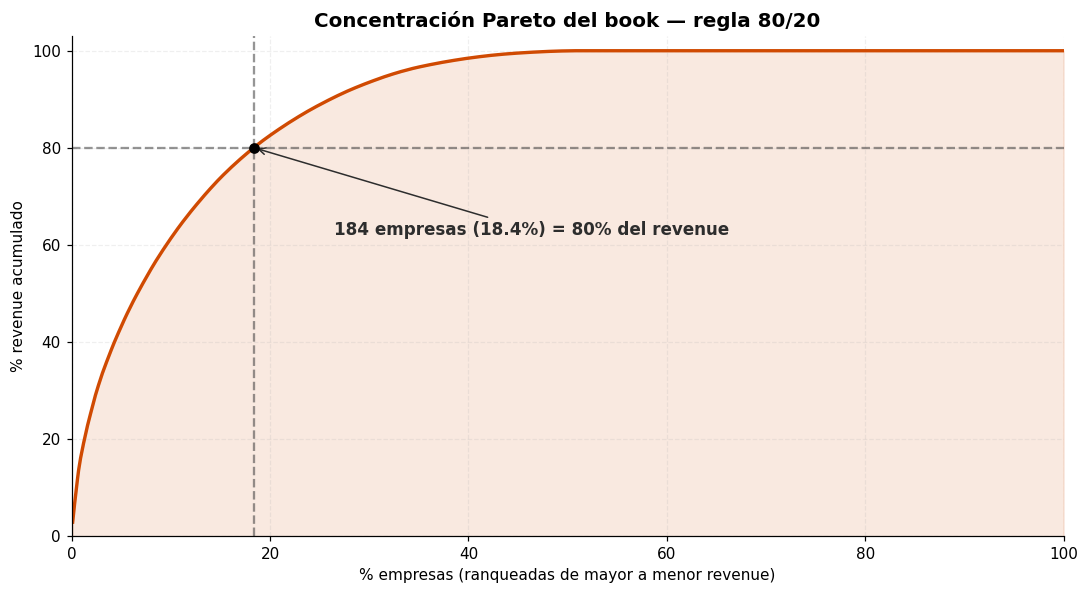

In [24]:
rev_sorted = seg["revenue_reciente"].sort_values(ascending=False).reset_index(drop=True)
cum = rev_sorted.cumsum()/rev_sorted.sum()*100
x = np.arange(1,len(rev_sorted)+1)/len(rev_sorted)*100
n_share = int((cum<=80).sum())+1
pct80 = n_share/len(rev_sorted)*100

fig, ax = plt.subplots(figsize=(10,5.5))
ax.plot(x, cum, color=PWC_ORANGE, linewidth=2.2)
ax.fill_between(x, 0, cum, alpha=0.12, color=PWC_ORANGE)
ax.axhline(80, color=PWC_DARK, linestyle="--", alpha=0.5)
ax.axvline(pct80, color=PWC_DARK, linestyle="--", alpha=0.5)
ax.scatter([pct80],[80], color="black", zorder=5)
ax.annotate(f"{n_share} empresas ({pct80:.1f}%) = 80% del revenue",
            xy=(pct80,80), xytext=(pct80+8,62), fontsize=11, fontweight="bold", color=PWC_DARK,
            arrowprops=dict(arrowstyle="->", color=PWC_DARK))
ax.set_xlabel("% empresas (ranqueadas de mayor a menor revenue)")
ax.set_ylabel("% revenue acumulado")
ax.set_title("Concentración Pareto del book — regla 80/20", fontweight="bold")
ax.grid(alpha=0.2, linestyle="--")
ax.set_xlim(0,100); ax.set_ylim(0,103)
plt.tight_layout(); plt.show()


### Gráfica 6 · Distribución Churn Risk (donut)


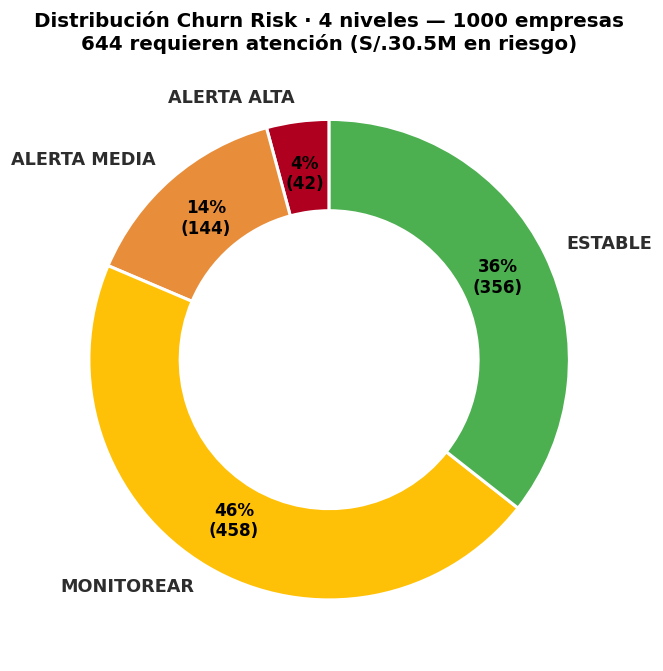

In [25]:
levels = ["ALERTA ALTA","ALERTA MEDIA","MONITOREAR","ESTABLE"]
counts = [kpis["churn_alta"], kpis["churn_media"], kpis["churn_monit"], kpis["churn_estable"]]
colors_donut = ["#B00020","#E88E3B","#FFC107","#4CAF50"]

# v7i: eliminar slices con 0 empresas (evita warnings de matplotlib)
labels_used  = [l for l,c in zip(levels,counts) if c>0]
counts_used  = [c for c   in counts             if c>0]
colors_used  = [col for col,c in zip(colors_donut,counts) if c>0]

fig, ax = plt.subplots(figsize=(8.6,6.2))
wedges, texts, autotexts = ax.pie(counts_used, labels=labels_used, colors=colors_used,
                                   autopct=lambda p: f"{p:.0f}%\n({int(round(p*sum(counts_used)/100))})",
                                   startangle=90, pctdistance=0.78,
                                   wedgeprops=dict(width=0.38, edgecolor="white", linewidth=2))
for t in autotexts: t.set_fontweight("bold"); t.set_color("black"); t.set_fontsize(11)
for t in texts:     t.set_fontsize(11.5); t.set_color(PWC_DARK); t.set_fontweight("bold")
accion = kpis['churn_alta']+kpis['churn_media']+kpis['churn_monit']
ax.set_title(f"Distribución Churn Risk · 4 niveles — {int(sum(counts))} empresas\n"
             f"{accion} requieren atención (S/.{kpis['revenue_en_riesgo_M']:.1f}M en riesgo)",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()


### Gráfica 7 · Upsell potential por cluster (revenue + margin)


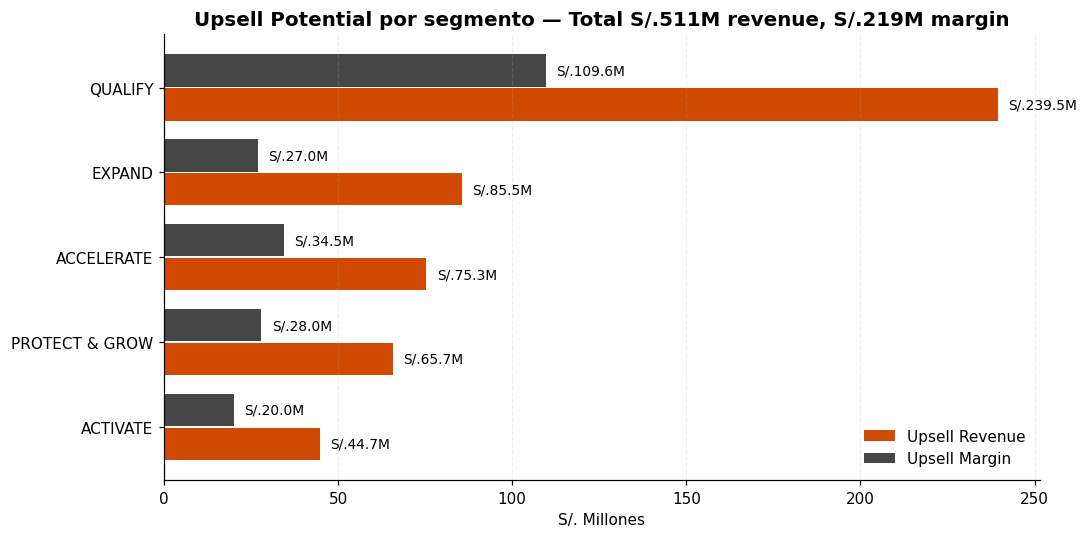

In [26]:
# Preparación de datos
ups = pd.DataFrame([{
    "cluster":cl,
    "rev_M":seg.loc[seg["cluster_name"]==cl,"upsell_revenue_potential"].sum()/1e6,
    "mgn_M":seg.loc[seg["cluster_name"]==cl,"upsell_margin_potential"].sum()/1e6,
} for cl in labels_order]).sort_values("rev_M")

# Definimos el tono gris oscuro (PwC Carbon)
PWC_DARK_GRAY = "#464646"

fig, ax = plt.subplots(figsize=(10,5))
y = np.arange(len(ups))

# Dibujamos las barras (Cambiamos el color de la segunda barra al gris oscuro)
b1 = ax.barh(y-0.2, ups["rev_M"], height=0.38, color=PWC_ORANGE, label="Upsell Revenue")
b2 = ax.barh(y+0.2, ups["mgn_M"], height=0.38, color=PWC_DARK_GRAY,  label="Upsell Margin")

# Etiquetas de texto
for b,v in zip(b1, ups["rev_M"]): ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, f"S/.{v:.1f}M", va="center", fontsize=9)
for b,v in zip(b2, ups["mgn_M"]): ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, f"S/.{v:.1f}M", va="center", fontsize=9)

# Formato del gráfico
ax.set_yticks(y)
ax.set_yticklabels(ups["cluster"])
ax.set_xlabel("S/. Millones")
ax.set_title(f"Upsell Potential por segmento — Total S/.{ups['rev_M'].sum():.0f}M revenue, S/.{ups['mgn_M'].sum():.0f}M margin", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.2, axis="x", linestyle="--")

plt.tight_layout()
plt.show()


### Gráfica 8 · Evolución de revenue por Sub-LoS (FY21-FY26)


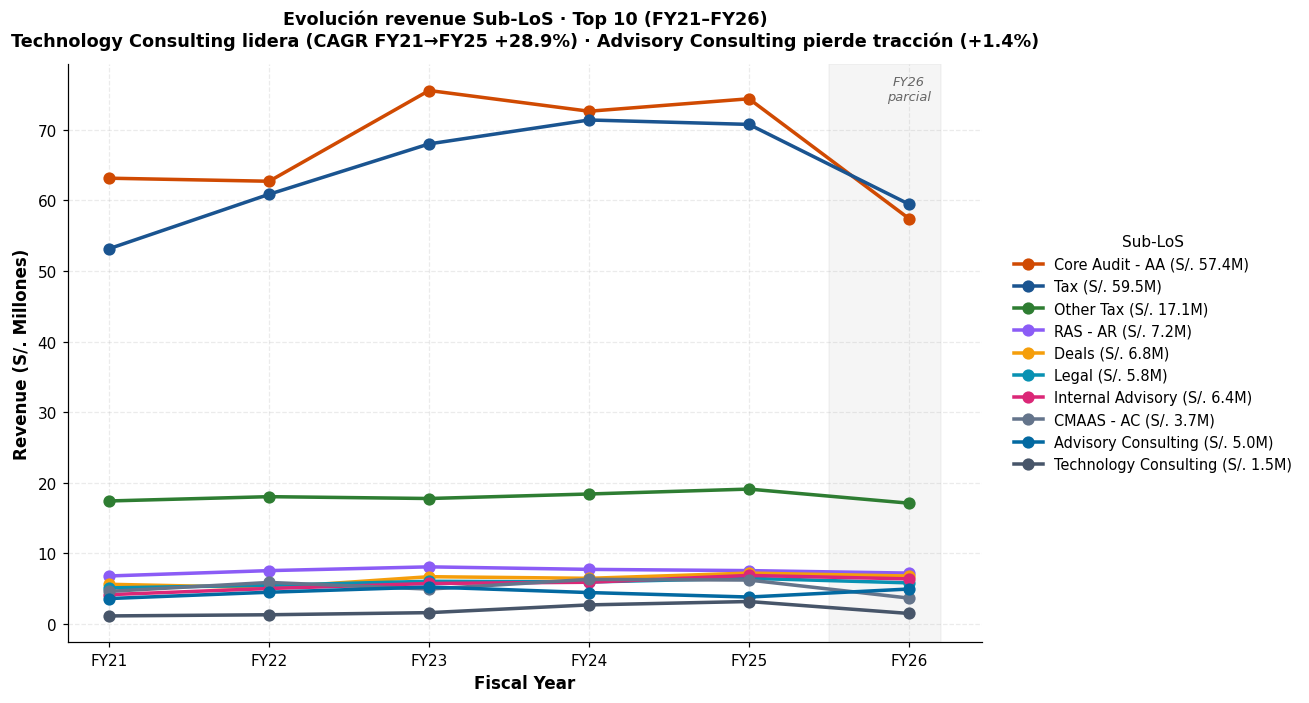

In [27]:
# 1. Cambiamos nlargest(8) a nlargest(10)
evo_full = (fin.groupby(["FY_int","Sub-LoS"])["Net Revenue"].sum().reset_index())
piv_full = evo_full.pivot(index="FY_int", columns="Sub-LoS", values="Net Revenue").fillna(0)/1e6
top_sublos = piv_full.sum(axis=0).nlargest(10).index.tolist()
pv = piv_full[top_sublos]

def _cagr(s,e,y):
    if s<=0 or e<=0 or y<=0: return None
    return (e/s)**(1/y)-1

cagrs = {sl: _cagr(pv.loc[2021,sl] if 2021 in pv.index else 0,
                   pv.loc[2025,sl] if 2025 in pv.index else 0, 4) for sl in top_sublos}
sorted_c = sorted([(sl,c) for sl,c in cagrs.items() if c is not None], key=lambda x:x[1])
loser  = sorted_c[0]  if sorted_c else (None,None)
winner = sorted_c[-1] if sorted_c else (None,None)

# 2. Agregamos dos colores más al final de la paleta (ej: Celeste oscuro y Gris oscuro)
palette_sl = ["#D04A02","#1A5490","#2E7D32","#8B5CF6","#F59E0B","#0891B2","#DB2777","#64748B", "#0369A1", "#475569"]
fig, ax = plt.subplots(figsize=(12,6.5))

for i, sl in enumerate(top_sublos):
    vals = pv[sl].values

    # Texto combinado para la leyenda
    texto_leyenda = f"{str(sl)[:25]} (S/. {vals[-1]:.1f}M)"

    ax.plot(pv.index, vals, marker="o", markersize=7, linewidth=2.3, color=palette_sl[i], label=texto_leyenda)

ax.set_xlabel("Fiscal Year", fontsize=11, fontweight="bold")
ax.set_ylabel("Revenue (S/. Millones)", fontsize=11, fontweight="bold")
ax.set_xticks(pv.index)
ax.set_xticklabels([f"FY{int(y)%100:02d}" for y in pv.index], fontsize=10)

hdr = ""
if winner[0] and loser[0]:
    hdr = f"{winner[0]} lidera (CAGR FY21→FY25 {winner[1]*100:+.1f}%) · {loser[0]} pierde tracción ({loser[1]*100:+.1f}%)"
# Actualizamos el título a Top 10
ax.set_title(f"Evolución revenue Sub-LoS · Top 10 (FY21–FY26)\n{hdr}", fontweight="bold", fontsize=11.5, pad=12)

ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), fontsize=9.5, frameon=False, title="Sub-LoS", title_fontsize=10)
ax.grid(alpha=0.25, linestyle="--")
ax.axvspan(2025.5, 2026.2, alpha=0.08, color="gray")
ax.text(2026, ax.get_ylim()[1]*0.98, "FY26\nparcial", ha="center", va="top", fontsize=8.5, style="italic", color="#666")

plt.tight_layout()
plt.show()


### Gráfica 9 · Evolución de revenue por Cost Center (FY21-FY26)


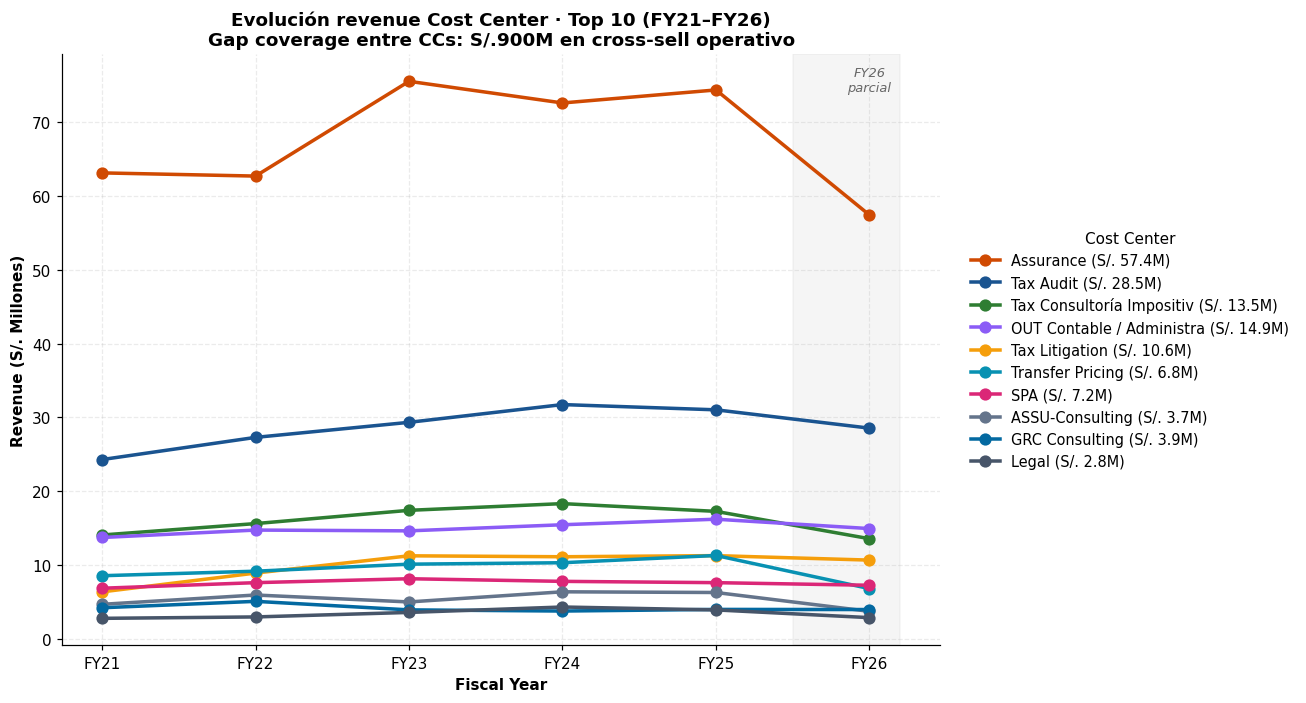

In [28]:
if "Cost Center" in fin.columns and "FY" in fin.columns:
    # 1. Cambiamos de Top 8 a Top 10
    top_cc = fin.groupby("Cost Center")["Net Revenue"].sum().nlargest(10).index.tolist()
    pv_cc = (fin[fin["Cost Center"].isin(top_cc)]
             .pivot_table(index="FY", columns="Cost Center", values="Net Revenue", aggfunc="sum")
             .fillna(0)/1e6)[top_cc]

    # 2. Agregamos dos colores más al final de la paleta
    palette_cc = ["#D04A02","#1A5490","#2E7D32","#8B5CF6","#F59E0B","#0891B2","#DB2777","#64748B", "#0369A1", "#475569"]
    fig, ax = plt.subplots(figsize=(12,6.5))

    for i, cc in enumerate(top_cc):
        vals = pv_cc[cc].values

        # 3. Formateamos la etiqueta para la leyenda incluyendo el valor final
        texto_leyenda = f"{str(cc)[:25]} (S/. {vals[-1]:.1f}M)"

        ax.plot(pv_cc.index, vals, marker="o", markersize=7, linewidth=2.3, color=palette_cc[i], label=texto_leyenda)

        # (El bloque ax.annotate fue eliminado para evitar manchas visuales)

    ax.set_xlabel("Fiscal Year", fontweight="bold")
    ax.set_ylabel("Revenue (S/. Millones)", fontweight="bold")
    ax.set_xticks(pv_cc.index)
    ax.set_xticklabels([f"FY{int(y)%100:02d}" for y in pv_cc.index])

    total_up_cc = seg["upsell_revenue_potential_cc"].sum()/1e6 if "upsell_revenue_potential_cc" in seg.columns else 0

    # 4. Actualizamos el título a Top 10
    ax.set_title(f"Evolución revenue Cost Center · Top 10 (FY21–FY26)\nGap coverage entre CCs: S/.{total_up_cc:.0f}M en cross-sell operativo",
                 fontweight="bold", fontsize=12)

    ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), fontsize=9.5, frameon=False, title="Cost Center", title_fontsize=10)
    ax.grid(alpha=0.25, linestyle="--")
    ax.axvspan(2025.5, 2026.2, alpha=0.08, color="gray")
    ax.text(2026, ax.get_ylim()[1]*0.98, "FY26\nparcial", ha="center", va="top", fontsize=8.5, style="italic", color="#666")
    plt.tight_layout(); plt.show()



### Gráfica 10 · Distribución de pérdidas Monte Carlo · VaR(95%) y CVaR(95%)
Histograma de 10,000 escenarios simulados. La cola roja (≥VaR) representa el 5% peor.


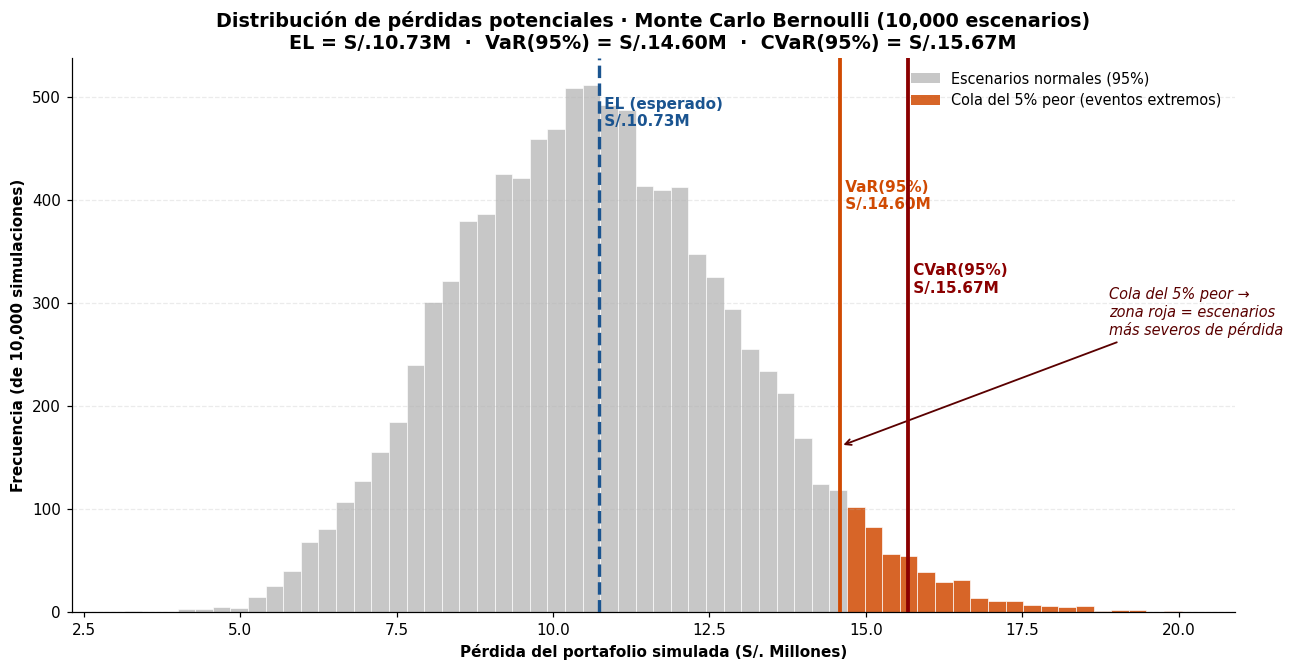

In [29]:
sim_M = sim_losses.astype(float)/1e6
EL_M  = EL_book/1e6
VaR_M = VaR_95/1e6
CVaR_M= CVaR_95/1e6

fig, ax = plt.subplots(figsize=(12,6.2))
n, bins, patches = ax.hist(sim_M, bins=60, color="#BDBDBD", edgecolor="white", linewidth=0.5, alpha=0.85)
for i, b in enumerate(bins[:-1]):
    if b >= VaR_M:
        patches[i].set_facecolor(PWC_ORANGE); patches[i].set_alpha(0.85)
ymax = ax.get_ylim()[1]
ax.axvline(EL_M,   color=PWC_BLUE,   linestyle="--", linewidth=2.2, zorder=5)
ax.axvline(VaR_M,  color=PWC_ORANGE, linestyle="-",  linewidth=2.5, zorder=5)
ax.axvline(CVaR_M, color="#8B0000",  linestyle="-",  linewidth=2.5, zorder=5)
ax.text(EL_M,   ymax*0.93, f" EL (esperado)\n S/.{EL_M:.2f}M",   color=PWC_BLUE,   fontsize=10, fontweight="bold", va="top")
ax.text(VaR_M,  ymax*0.78, f" VaR(95%)\n S/.{VaR_M:.2f}M",       color=PWC_ORANGE, fontsize=10, fontweight="bold", va="top")
ax.text(CVaR_M, ymax*0.63, f" CVaR(95%)\n S/.{CVaR_M:.2f}M",     color="#8B0000",  fontsize=10, fontweight="bold", va="top")
ax.annotate("Cola del 5% peor →\nzona roja = escenarios\nmás severos de pérdida",
            xy=(VaR_M, ymax*0.30), xytext=(VaR_M+(CVaR_M-VaR_M)*4, ymax*0.50),
            fontsize=9.5, color="#5A0000", style="italic",
            arrowprops=dict(arrowstyle="->", color="#5A0000", lw=1.2))
ax.set_xlabel("Pérdida del portafolio simulada (S/. Millones)", fontweight="bold")
ax.set_ylabel("Frecuencia (de 10,000 simulaciones)", fontweight="bold")
ax.set_title(f"Distribución de pérdidas potenciales · Monte Carlo Bernoulli (10,000 escenarios)\n"
             f"EL = S/.{EL_M:.2f}M  ·  VaR(95%) = S/.{VaR_M:.2f}M  ·  CVaR(95%) = S/.{CVaR_M:.2f}M",
             fontweight="bold", fontsize=12.5)
ax.grid(alpha=0.25, linestyle="--", axis="y")
ax.legend(handles=[Patch(facecolor="#BDBDBD",alpha=0.85,label="Escenarios normales (95%)"),
                   Patch(facecolor=PWC_ORANGE,alpha=0.85,label="Cola del 5% peor (eventos extremos)")],
          loc="upper right", frameon=False, fontsize=9.5)
plt.tight_layout(); plt.show()


### Gráfica 11 · Riesgo (EL) vs Oportunidad (Upsell) por cluster


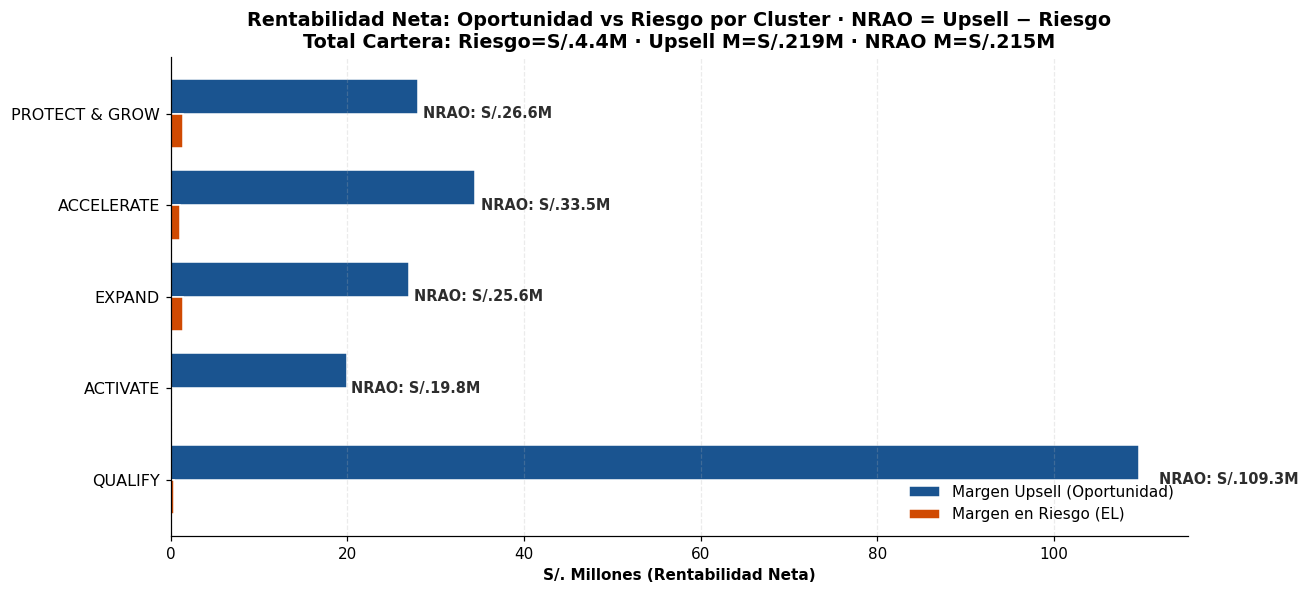

In [39]:
rb = pd.DataFrame([{
    "cluster": cl,
    "EL_Margin_M":  seg.loc[seg["cluster_name"]==cl,"EL_margin"].sum()/1e6,               # <-- Actualizado a Margen
    "UPS_Margin_M": seg.loc[seg["cluster_name"]==cl,"upsell_margin_potential"].sum()/1e6, # <-- Actualizado a Margen
    "NRAO_M":       seg.loc[seg["cluster_name"]==cl,"NRAO"].sum()/1e6,
} for cl in labels_order]).set_index("cluster")

fig, ax = plt.subplots(figsize=(12,5.5))
y = np.arange(len(rb)); h = 0.38

# Las barras ahora grafican Margen vs Margen
ax.barh(y-h/2, rb["UPS_Margin_M"], height=h, color=PWC_BLUE,   edgecolor="white", label="Margen Upsell (Oportunidad)")
ax.barh(y+h/2, rb["EL_Margin_M"],  height=h, color=PWC_ORANGE, edgecolor="white", label="Margen en Riesgo (EL)")

ax.set_yticks(y); ax.set_yticklabels(rb.index, fontsize=10.5); ax.invert_yaxis()
ax.set_xlabel("S/. Millones (Rentabilidad Neta)", fontweight="bold") # <-- Aclaración en el eje X

# Título ajustado al lenguaje de la alta gerencia
ax.set_title(f"Rentabilidad Neta: Oportunidad vs Riesgo por Cluster · NRAO = Upsell − Riesgo\n"
             f"Total Cartera: Riesgo=S/.{rb['EL_Margin_M'].sum():.1f}M · Upsell M=S/.{rb['UPS_Margin_M'].sum():.0f}M · NRAO M=S/.{rb['NRAO_M'].sum():.0f}M",
             fontweight="bold", fontsize=12.5)

for i, (cl, r) in enumerate(rb.iterrows()):
    # Se ajusta la posición del texto usando las nuevas variables de Margen
    ax.text(max(r["UPS_Margin_M"], r["EL_Margin_M"])*1.02, i, f"NRAO: S/.{r['NRAO_M']:.1f}M",
            va="center", fontsize=9.5, fontweight="bold", color=PWC_DARK)

ax.legend(loc="lower right", frameon=False, fontsize=10)
ax.grid(alpha=0.25, linestyle="--", axis="x")
plt.tight_layout(); plt.show()

### Gráfica 12 · Pesos del Target Score


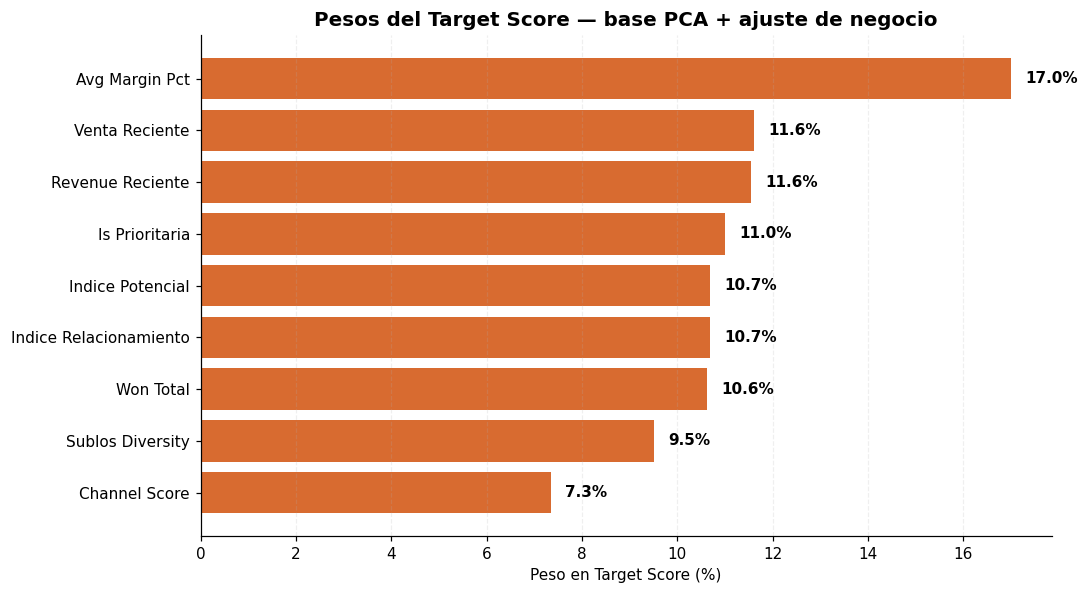

In [32]:
w_items = sorted(feature_weights.items(), key=lambda x:-x[1])
names = [n.replace("_imputed","").replace("_"," ").title() for n,_ in w_items]
vals  = [v*100 for _,v in w_items]
fig, ax = plt.subplots(figsize=(10,5.5))
bars = ax.barh(names[::-1], vals[::-1], color=PWC_ORANGE, alpha=0.82)
for b,v in zip(bars, vals[::-1]):
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f"{v:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Peso en Target Score (%)")
ax.set_title("Pesos del Target Score — base PCA + ajuste de negocio", fontweight="bold")
ax.grid(alpha=0.2, axis="x", linestyle="--")
plt.tight_layout(); plt.show()


## 11. Top 10 Empresas Estratégicas
Combinación ponderada: 35% score, 25% upsell, 20% (1-churn), 20% revenue.


In [33]:
def norm(s):
    mn, mx = s.min(), s.max()
    return (s-mn)/(mx-mn+1e-9)

seg["score_n"]  = norm(seg["Target_Score"])
seg["upsell_n"] = norm(seg["upsell_revenue_potential"])
seg["churn_inv"]= 1 - norm(seg["churn_risk_score"])
seg["rev_n"]    = norm(seg["revenue_reciente"])
seg["strategic_score"] = seg["score_n"]*0.35 + seg["upsell_n"]*0.25 + seg["churn_inv"]*0.20 + seg["rev_n"]*0.20

top_strat = seg.nlargest(10, "strategic_score")[[
    "razon_social","cluster_name","Target_Score","revenue_reciente",
    "upsell_revenue_potential","churn_risk_level","is_prioritaria","missing_los_str"
]].copy()
top_strat["revenue_M"] = top_strat["revenue_reciente"]/1e6
top_strat["upsell_M"]  = top_strat["upsell_revenue_potential"]/1e6
display(top_strat[["razon_social","cluster_name","Target_Score","revenue_M","upsell_M",
                   "churn_risk_level","is_prioritaria","missing_los_str"]])


,razon_social,cluster_name,Target_Score,revenue_M,upsell_M,churn_risk_level,is_prioritaria,missing_los_str
4,SOCIEDAD MINERA CERRO VERDE S.A.A.,PROTECT & GROW,89.48,3.10,2.78,ESTABLE,1,"Advisory Consulting, Core Audit - AA, Deals, I..."
20,SCOTIABANK PERU S.A.A.,PROTECT & GROW,82.03,2.60,2.80,ESTABLE,1,"Advisory Consulting, CMAAS - AC, Core Audit - ..."
32,CIA. MINERA ANTAPACCAY S.A.,PROTECT & GROW,82.68,2.82,2.50,ESTABLE,1,"CMAAS - AC, Core Audit - AA, Deals, Internal A..."
41,MINSUR S.A.,PROTECT & GROW,88.35,1.95,2.38,ESTABLE,1,"Advisory Consulting, Core Audit - AA, Other Ta..."
129,GOLD FIELDS LA CIMA S.A.,PROTECT & GROW,73.90,2.85,2.35,ESTABLE,1,"Advisory Consulting, Deals, Internal Advisory,..."
26,INTEGRATEL PERÚ S.A.A.,PROTECT & GROW,54.26,4.71,2.35,ESTABLE,0,"Advisory Consulting, Deals, Internal Advisory,..."
105,MARCOBRE S.A.C.,PROTECT & GROW,86.00,1.64,2.23,ESTABLE,1,"Core Audit - AA, Deals, Other Tax, Strategy Co..."
35,LUZ DEL SUR S.A.A.,PROTECT & GROW,75.34,3.23,1.46,ESTABLE,0,"Deals, Internal Advisory, Legal, Other Tax, St..."
96,NEXA RESOURCES PERU S.A.A.,PROTECT & GROW,69.26,1.52,2.35,ESTABLE,1,"Advisory Consulting, Deals, Internal Advisory,..."
440,JETSMART AIRLINES PERU S.A.C.,PROTECT & GROW,63.53,2.87,1.87,ESTABLE,0,"Advisory Consulting, CMAAS - AC, Core Audit - ..."


## 12. Top 10 Hidden Gems (infravaloradas)
Empresas fuera de PROTECT&GROW con revenue >150K, ≥2 Sub-LoS faltantes y upsell >100K.


In [34]:
seg["n_missing"] = seg["missing_los"].apply(lambda x: len(x) if isinstance(x,list) else 0)
cand = seg[(seg["cluster_name"]!="PROTECT & GROW") & (seg["revenue_reciente"]>150_000) &
           (seg["n_missing"]>=2) & (seg["upsell_revenue_potential"]>100_000)].copy()
if len(cand):
    cand["undervalued"] = (norm(cand["upsell_revenue_potential"])*0.35 +
                           norm(cand["revenue_reciente"])*0.25 +
                           (1-norm(cand["churn_risk_score"]))*0.20 +
                           (1-norm(cand["Target_Score"]))*0.20)
    top_under = cand.nlargest(10,"undervalued")[[
        "razon_social","cluster_name","Target_Score","revenue_reciente",
        "upsell_revenue_potential","churn_risk_level","is_prioritaria","n_missing","missing_los_str"
    ]].copy()
    top_under["revenue_M"] = top_under["revenue_reciente"]/1e6
    top_under["upsell_M"]  = top_under["upsell_revenue_potential"]/1e6
    display(top_under[["razon_social","cluster_name","Target_Score","revenue_M","upsell_M",
                       "churn_risk_level","is_prioritaria","n_missing","missing_los_str"]])
else:
    print("Sin candidatos para Hidden Gems con los filtros actuales.")


,razon_social,cluster_name,Target_Score,revenue_M,upsell_M,churn_risk_level,is_prioritaria,n_missing,missing_los_str
515,SIEMENS ENERGY S.A.C.,EXPAND,32.93,1.25,0.49,ESTABLE,0,9,"Advisory Consulting, CMAAS - AC, Core Audit - ..."
917,BASF PERUANA S.A.,EXPAND,25.88,0.78,0.64,ESTABLE,0,11,"Advisory Consulting, CMAAS - AC, Core Audit - ..."
171,EXSA S.A.,ACCELERATE,45.19,0.76,0.82,ESTABLE,0,9,"Advisory Consulting, Core Audit - AA, Deals, I..."
497,INDUSTRIAS ELECTRO QUIMICAS S.A.,ACCELERATE,43.13,0.67,0.84,ESTABLE,0,10,"Advisory Consulting, CMAAS - AC, Core Audit - ..."
667,TD SYNNEX PERU S.A.C.,ACCELERATE,43.04,0.70,0.79,ESTABLE,0,8,"Advisory Consulting, CMAAS - AC, Core Audit - ..."
225,GENERAL MOTORS PERU S.A.,ACCELERATE,34.84,0.43,0.84,ESTABLE,0,10,"Advisory Consulting, CMAAS - AC, Core Audit - ..."
118,UNIVERSIDAD PERUANA DE CIENCIAS APLICADAS S.A.C.,EXPAND,38.54,1.26,0.42,ESTABLE,0,9,"Advisory Consulting, CMAAS - AC, Deals, Intern..."
193,VIRU GROUP PERU S.A.,ACCELERATE,41.17,0.20,0.98,ESTABLE,0,10,"Advisory Consulting, CMAAS - AC, Core Audit - ..."
22,VALERO PERU S.A.C.,ACCELERATE,46.93,0.59,0.82,ESTABLE,0,9,"Advisory Consulting, Core Audit - AA, Deals, I..."
501,BANCO GNB PERU S.A.,ACCELERATE,59.19,0.88,0.77,ESTABLE,1,9,"Advisory Consulting, CMAAS - AC, Deals, Intern..."


## 13. Empresas con Flag de Inconsistencia
Score alto (≥P75) pero ventas FY25 cayeron vs FY24 — desviación entre el modelo y la tendencia real.


In [35]:
inc = seg[seg["inconsistency_flag"]==1][[
    "razon_social","cluster_name","Target_Score","Venta FY24 PWC","Venta FY25 PWC","venta_delta_24_25",
    "churn_risk_level","is_prioritaria"
]].sort_values("venta_delta_24_25").head(20).copy()
inc["delta_M"] = inc["venta_delta_24_25"]/1e6
print(f"Total flags de inconsistencia: {seg['inconsistency_flag'].sum()} empresas")
display(inc[["razon_social","cluster_name","Target_Score","Venta FY24 PWC","Venta FY25 PWC",
             "delta_M","churn_risk_level","is_prioritaria"]])


Total flags de inconsistencia: 104 empresas


,razon_social,cluster_name,Target_Score,Venta FY24 PWC,Venta FY25 PWC,delta_M,churn_risk_level,is_prioritaria
23,ALICORP S.A.A.,PROTECT & GROW,69.35,"1,936,908.41","1,021,967.88",-0.91,ALERTA MEDIA,0
431,UNACEM CORP S.A.A.,PROTECT & GROW,65.02,"1,830,192.91","918,202.43",-0.91,ALERTA MEDIA,1
443,UNIVERSIDAD DE SAN MARTIN DE PORRES,EXPAND,37.97,"1,219,170.55","521,619.26",-0.70,ALERTA MEDIA,0
0,BANCO DE CREDITO DEL PERU,PROTECT & GROW,87.13,"2,018,457.20","1,440,711.86",-0.58,ALERTA MEDIA,1
427,ORAZUL ENERGY PERU S.A.,ACCELERATE,44.43,"758,835.74","228,628.89",-0.53,ALERTA MEDIA,0
530,HERMES TRANSPORTES BLINDADOS S.A.,ACCELERATE,52.36,"524,365.79","8,402.09",-0.52,ALERTA MEDIA,1
358,LIMA EXPRESA S.A.C.,EXPAND,56.77,"832,323.98","334,454.12",-0.50,ALERTA MEDIA,1
628,ADMINISTRADORA JOCKEY PLAZA SHOPPING CENTER S.A.,ACCELERATE,58.31,"720,385.13","248,827.66",-0.47,ALERTA MEDIA,1
254,FINANCIERA SANTANDER CONSUMER S.A.,EXPAND,49.57,"437,205.80",0.00,-0.44,ALERTA MEDIA,1
139,ORICA MINING SERVICES PERU S.A.,PROTECT & GROW,44.17,"1,039,914.54","624,552.38",-0.42,ALERTA MEDIA,0


## 14. (Opcional) Exportar resultados a Excel y pickle


In [36]:
# Exporta el dataset enriquecido a Excel + pickle + risk summary json
out_xlsx = os.path.join(HERE, "Segmentacion_Resultados_v7i.xlsx")
out_pkl  = os.path.join(HERE, "seg_processed_v7i.pkl")
out_json = os.path.join(HERE, "risk_alvaro_v7i.json")

cols_export = [
    "PRID","RUC","razon_social","cluster_name","Target_Score",
    "revenue_reciente","venta_reciente","avg_margin_pct_imputed",
    "is_prioritaria","indice_potencial","indice_relacionamiento",
    "won_total","sublos_diversity","channel_score",
    "churn_risk_score","churn_risk_level",
    "upsell_revenue_potential","upsell_margin_potential","missing_los_str",
    "PD","EAD","EL_empresa","NRAO","inconsistency_flag",
    "VaR_Revenue","NRAO_det","venta_falling","desviacion_modelo",
]
cols_export = [c for c in cols_export if c in seg.columns]
seg[cols_export].to_excel(out_xlsx, index=False, sheet_name="Empresas")
seg.to_pickle(out_pkl)

import json as _json
with open(out_json, "w", encoding="utf-8") as f:
    _json.dump(risk_alvaro_summary, f, indent=2, default=float)

print(f"OK: {out_xlsx}")
print(f"OK: {out_pkl}")
print(f"OK: {out_json}")


OK: /content/Segmentacion_Resultados_v7i.xlsx
OK: /content/seg_processed_v7i.pkl
OK: /content/risk_alvaro_v7i.json


---
**v7i · 18.04.2026** · Notebook autocontenido · 1,000 empresas · Pipeline completo + 13 visualizaciones inline
**Cambios v7i:** (1) Donut con 4 niveles (MONITOREAR incluido), (2) Risk Analytics ejecutivo (VaR determinista, CVaR top 5% score, NRAO_det, Desviación de Modelo), (3) Gráfica VaR vs Upsell por cluster, (4) Radar con normalización percentil del book.
